
# Same Patient, Different Explanations?

### A Comparative Study to evaluate SHAP's Consistency Across ML Models in healthcare.

This project provides a systematic, empirical test. We train two structurally different models (XGBoost and a multilayer perceptron) on four healthcare datasets spanning two diseases, generate SHAP explanations for each, and measure whether those explanations agree — globally and at the individual patient level. By replicating the comparison across two diabetes datasets and two heart disease datasets, we can determine whether any divergence pattern is a property of the model architecture, the dataset, or both.

**Resaerch Question**

When two structurally different machine learning models are trained on the same healthcare dataset and explained with SHAP, do they provide the same account of why a given prediction was made — and does any observed divergence replicate across different healthcare prediction tasks?

**Sub-Questions**

1.	Within-dataset: Do the models agree on which features drive predictions, both globally (feature rankings) and locally (individual patients)?
2.	Cross-dataset within disease: Does the pattern of agreement or divergence replicate across two different datasets for the same disease? For example, if XGBoost and MLP diverge on Pima Diabetes, do they also diverge on the Kaggle Diabetes Prediction dataset?
3.	Cross-disease: Is the divergence pattern consistent across disease domains (diabetes vs heart disease), or is it disease-specific?
4.	Governance implications: If explanations diverge, how must we re-evaluate the definition of “regulatory transparency” in clinical AI deployment?



### Cell 1: Dependencies

In [ ]:
# Install dependencies needed for PyTorch, SHAP, and XGBoost
%pip install -q torch shap scipy xgboost scikit-learn pandas numpy matplotlib seaborn



### Constants

SEED = 42
TEST_SIZE = 0.2
PIMA_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

import random
random.seed(SEED)

### Cell 2: Initialization & Data Loading

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
base_dir = Path.cwd()

datasets = {
    "pima_diabetes": {
        "csv": base_dir / "Pima Indians Diabetes Dataset.csv",
        "doc": base_dir / "Pima Indians Diabetes columns meaning.txt",
    },
    "diabetes_prediction": {
        "csv": base_dir / "diabetes_prediction_dataset.csv",
        "doc": base_dir / "Diabetes prediction dataset columns meaning.txt",
    },
    "uci_heart": {
        "csv": base_dir / "UCI Heart Disease.csv",
        "doc": base_dir / "UCI Heart Disease Dataset column meaning.txt",
    },
    "heart_disease_prediction": {
        "csv": base_dir / "framingham_cleaned.csv",
        "doc": base_dir / "heart disease prediction dataset column meaning.txt",
    },
}

loaded = {}
for name, paths in datasets.items():
    if not paths["csv"].exists():
        raise FileNotFoundError(f"Missing file: {paths['csv']}")
    loaded[name] = pd.read_csv(paths["csv"])

display(pd.DataFrame({
    "dataset": list(loaded.keys()),
    "rows": [df.shape[0] for df in loaded.values()],
    "cols": [df.shape[1] for df in loaded.values()],
}))

,dataset,rows,cols
0,pima_diabetes,768,9
1,diabetes_prediction,100000,9
2,uci_heart,1025,14
3,heart_disease_prediction,4238,16


### Cell 3: Dataset Preview

In [ ]:
for name, df in loaded.items():
    print(f"\n=== {name} ===")
    display(df.head(5))
    display(df.dtypes.to_frame(name="dtype"))

    doc_path = datasets[name]["doc"]
    if doc_path.exists():
        print(f"\nColumn meanings file: {doc_path.name}")
        with open(doc_path, "r", encoding="utf-8", errors="ignore") as f:
            preview = "".join(f.readlines()[:25])
        print(preview)
    else:
        print("No column-meaning documentation file found.")


=== pima_diabetes ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Column meanings file: Pima Indians Diabetes columns meaning.txt
Pregnancies
Number of times pregnant

Glucose
Plasma glucose concentration a 2 hours in an oral glucose tolerance test

BloodPressure
Diastolic blood pressure (mm Hg)

SkinThickness
Triceps skin fold thickness (mm)

Insulin
2-Hour serum insulin (mu U/ml)

BMI
Body mass index (weight in kg/(height in m)^2)

DiabetesPedigreeFunction
Diabetes pedigree function

Age
Age (years)

Outcome


=== diabetes_prediction ===


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


...

,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Column meanings file: UCI Heart Disease Dataset column meaning.txt
age
age in years

sex
(1 = male; 0 = female)

cp
chest pain type

trestbps
resting blood pressure (in mm Hg on admission to the hospital)

chol
serum cholestoral in mg/dl

fbs
(fasting blood sugar &gt; 120 mg/dl) (1 = true; 0 = false)

restecg
resting electrocardiographic results

thalach
maximum heart rate achieved

exang


=== heart_disease_prediction ===


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


,dtype
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64



Column meanings file: heart disease prediction dataset column meaning.txt
Sex: male or female(Nominal)
• Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)
Behavioral
• Current Smoker: whether or not the patient is a current smoker (Nominal)
• Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
Medical( history)
• BP Meds: whether or not the patient was on blood pressure medication (Nominal)
• Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
• Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
• Diabetes: whether or not the patient had diabetes (Nominal)
Medical(current)
• Tot Chol: total cholesterol level (Continuous)
• Sys BP: systolic blood pressure (Continuous)
• Dia BP: diastolic blood pressure (Continuous)
• BMI: Body

### Cell 4: Missingness Analysis


=== pima_diabetes missingness ===


,missing,missing_pct
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


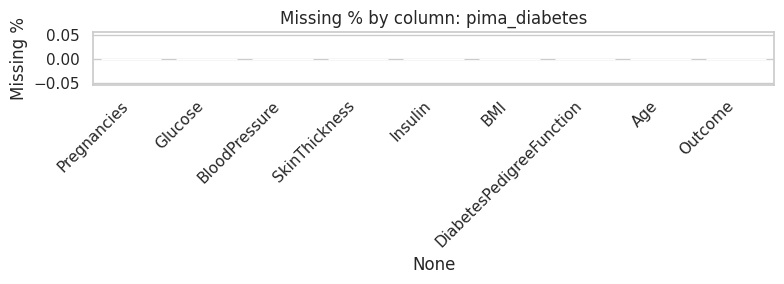


=== diabetes_prediction missingness ===


,missing,missing_pct
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0


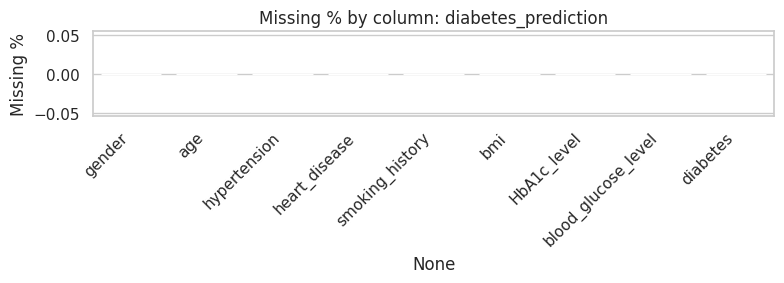


=== uci_heart missingness ===


,missing,missing_pct
age,0,0.0
sex,0,0.0
cp,0,0.0
trestbps,0,0.0
chol,0,0.0
fbs,0,0.0
restecg,0,0.0
thalach,0,0.0
exang,0,0.0
oldpeak,0,0.0


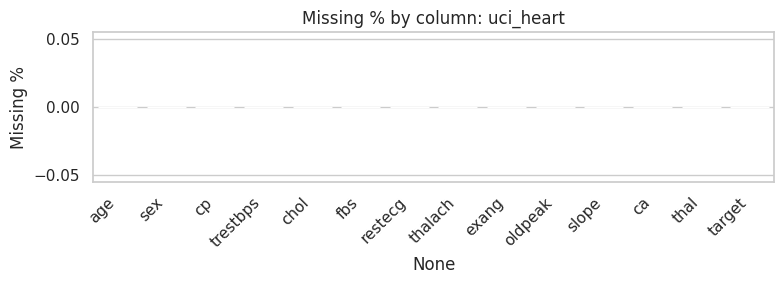


=== heart_disease_prediction missingness ===


,missing,missing_pct
male,0,0.0
age,0,0.0
education,0,0.0
currentSmoker,0,0.0
cigsPerDay,0,0.0
BPMeds,0,0.0
prevalentStroke,0,0.0
prevalentHyp,0,0.0
diabetes,0,0.0
totChol,0,0.0


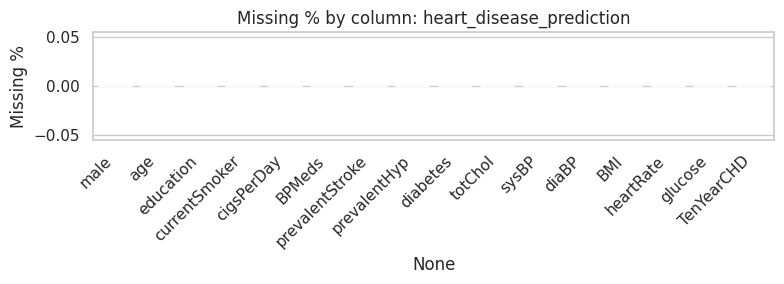

In [ ]:
def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    total = df.isna().sum()
    pct = (total / len(df) * 100).round(2)
    return pd.DataFrame({"missing": total, "missing_pct": pct}).sort_values("missing_pct", ascending=False)

for name, df in loaded.items():
    print(f"\n=== {name} missingness ===")
    miss = missingness_table(df)
    display(miss)

    plt.figure(figsize=(8, 3))
    sns.barplot(x=miss.index, y=miss["missing_pct"], color="#4C72B0")
    plt.title(f"Missing % by column: {name}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()

### Cell 5: Data Cleaning

In [ ]:
# ============================================================
# CLEAN: Pima Diabetes — Replace disguised zeros
# NOTE: Pima reports 0% missing but uses 0 as placeholder for
# missing data in 5 columns where 0 is biologically impossible.
# Reference: PMC (2022) article PMC8943493
# ============================================================
PIMA_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

pima_clean = loaded["pima_diabetes"].copy()

print("=== Pima: Disguised zeros → median imputation ===\n")
for col in PIMA_ZERO_COLS:
    n_zeros = (pima_clean[col] == 0).sum()
    pima_clean[col] = pima_clean[col].replace(0, np.nan)
    median_val = pima_clean[col].median()
    pima_clean[col] = pima_clean[col].fillna(median_val)
    print(f"  {col}: {n_zeros} zeros → median = {median_val:.1f}")

assert pima_clean.isna().sum().sum() == 0
loaded["pima_diabetes"] = pima_clean  # Update the loaded dict
print(f"\n Pima cleaned: {pima_clean.shape}, 0 missing")

=== Pima: Disguised zeros → median imputation ===

  Glucose: 5 zeros → median = 117.0
  BloodPressure: 35 zeros → median = 72.0
  SkinThickness: 227 zeros → median = 29.0
  Insulin: 374 zeros → median = 125.0
  BMI: 11 zeros → median = 32.3

✅ Pima cleaned: (768, 9), 0 missing


In [ ]:
# ============================================================
# CLEAN: Kaggle Diabetes — Encode categorical columns
# NOTE: gender and smoking_history are strings, models need numbers.
# "No Info" in smoking_history kept as category 0 (35.8% of data,
# too much to drop).
# ============================================================
diab_clean = loaded["diabetes_prediction"].copy()

print("=== Kaggle Diabetes: Encoding categoricals ===\n")

gender_map = {"Female": 0, "Male": 1, "Other": 2}
diab_clean["gender"] = diab_clean["gender"].map(gender_map)
print(f"gender: {gender_map}")

smoking_map = {
    "No Info": 0, "never": 1, "former": 2,
    "not current": 3, "current": 4, "ever": 5,
}
diab_clean["smoking_history"] = diab_clean["smoking_history"].map(smoking_map)
print(f"smoking_history: {smoking_map}")

loaded["diabetes_prediction"] = diab_clean  # Update the loaded dict
print(f"\n Kaggle Diabetes cleaned: {diab_clean.shape}, 0 object columns")

=== Kaggle Diabetes: Encoding categoricals ===

gender: {'Female': 0, 'Male': 1, 'Other': 2}
smoking_history: {'No Info': 0, 'never': 1, 'former': 2, 'not current': 3, 'current': 4, 'ever': 5}

✅ Kaggle Diabetes cleaned: (100000, 9), 0 object columns


In [ ]:
# ============================================================
# CLEAN: UCI Heart — Remove duplicate rows
# NOTE: This Kaggle version has 723 duplicate rows (1025 → 302).
# Reference: Scientific Reports (2025) "after preprocessing
# and removing duplicate entries"
# ============================================================
uci_clean = loaded["uci_heart"].copy()
n_before = len(uci_clean)
uci_clean = uci_clean.drop_duplicates()
n_removed = n_before - len(uci_clean)
loaded["uci_heart"] = uci_clean  # Update the loaded dict
print(f"UCI Heart: {n_removed} duplicates removed ({n_before} → {len(uci_clean)} rows)")

UCI Heart: 0 duplicates removed (302 → 302 rows)


### Cell 6: Target Variable Identification


=== pima_diabetes target: Outcome ===


,count,proportion
Outcome,,
0,500,0.651
1,268,0.349


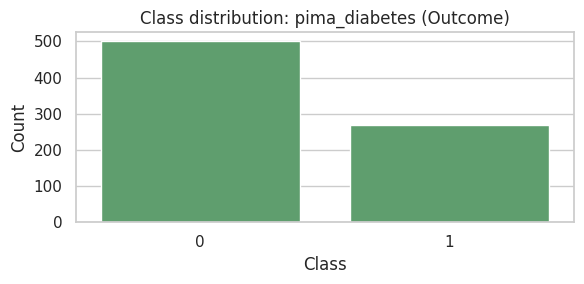


=== diabetes_prediction target: diabetes ===


,count,proportion
diabetes,,
0,91500,0.915
1,8500,0.085


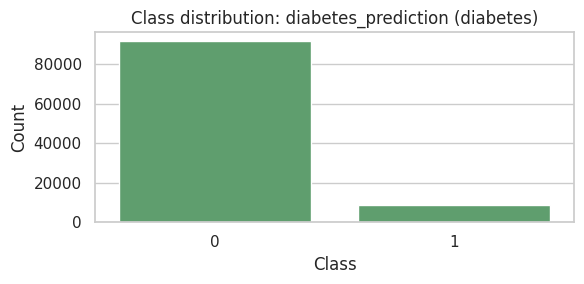


=== uci_heart target: target ===


,count,proportion
target,,
1,164,0.543
0,138,0.457


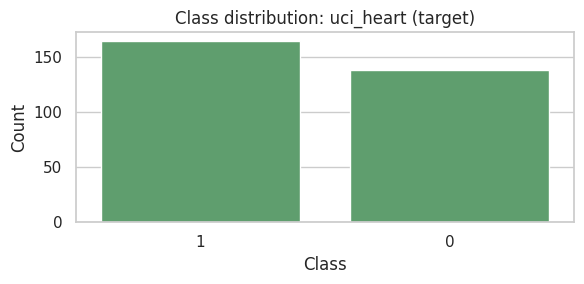


=== heart_disease_prediction target: TenYearCHD ===


,count,proportion
TenYearCHD,,
0,3594,0.848
1,644,0.152


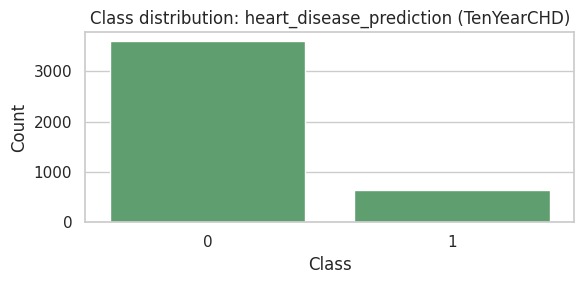

In [ ]:
# Fixed: Removed the trailing commas that turned these into unhashable tuples
candidate_targets = [
    "Outcome", "outcome", "Diabetes", "diabetes",
    "Diabetes_012", "target", "Target", "HeartDisease",
    "heart_disease", "HeartDiseaseorAttack", "TenYearCHD"
]

manual_target_map = {
    "pima_diabetes": "Outcome",
    "diabetes_prediction": "diabetes",
    "uci_heart": "target",
    "heart_disease_prediction": "TenYearCHD",
}

def guess_target(df: pd.DataFrame, name: str) -> str | None:
    if name in manual_target_map and manual_target_map[name] in df.columns:
        return manual_target_map[name]
    for col in candidate_targets:
        if col in df.columns:
            return col
    return None

class_imbalance = {}
for name, df in loaded.items():
    target = guess_target(df, name)
    print(f"\n=== {name} target: {target} ===")
    if target is None:
        print("No target column found. Update manual_target_map if needed.")
        continue

    counts = df[target].value_counts(dropna=False)
    proportions = (counts / counts.sum()).round(4)
    class_imbalance[name] = {
        "target": target,
        "counts": counts,
        "proportions": proportions,
        "imbalance_ratio": round(counts.max() / counts.min(), 2) if counts.min() > 0 else np.nan,
    }

    display(pd.DataFrame({"count": counts, "proportion": proportions}))

    plt.figure(figsize=(6, 3))
    sns.barplot(x=counts.index.astype(str), y=counts.values, color="#55A868")
    plt.title(f"Class distribution: {name} ({target})")
    plt.ylabel("Count")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.show()

### Cell 7: Correlation Analysis

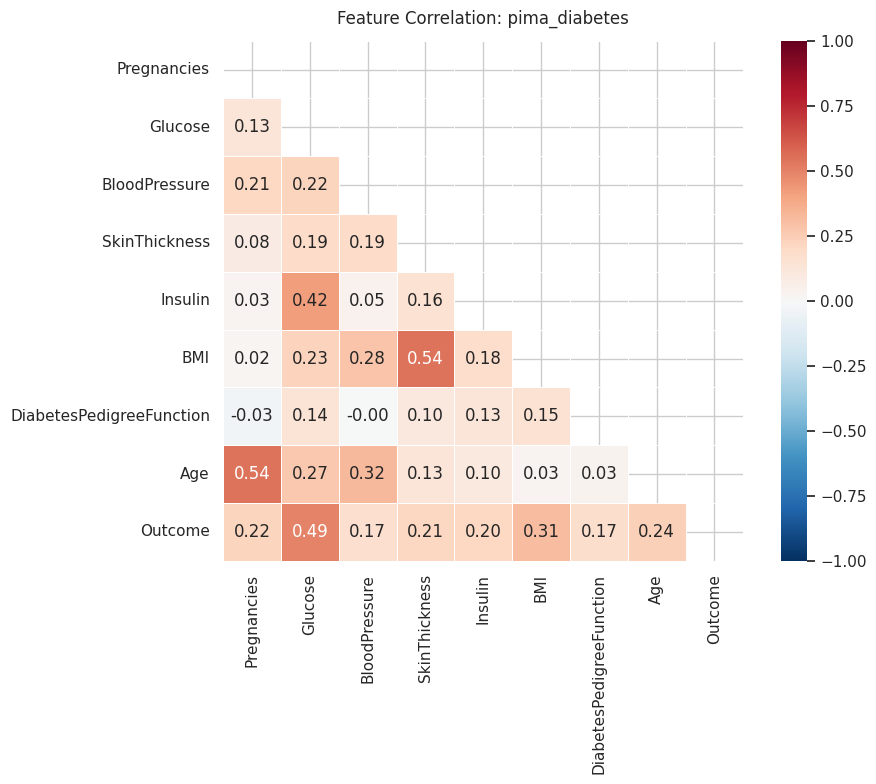

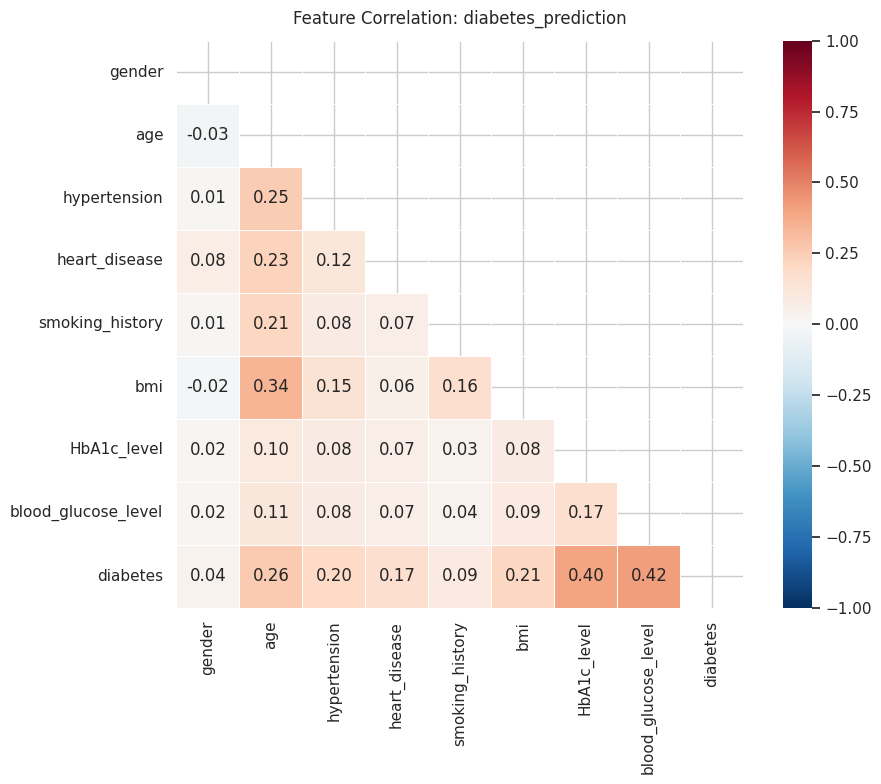

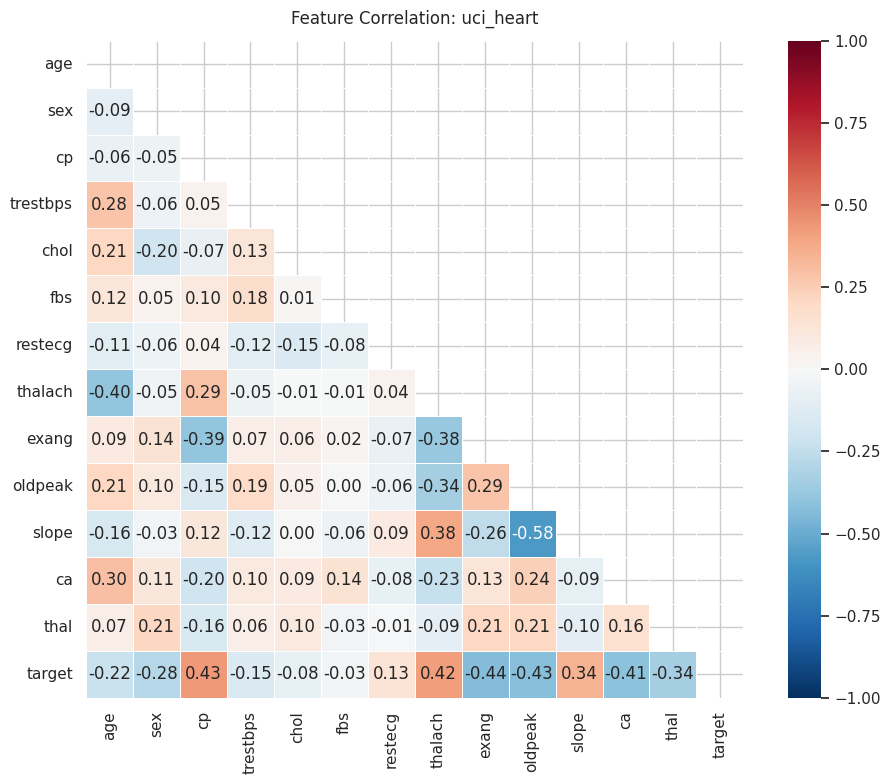

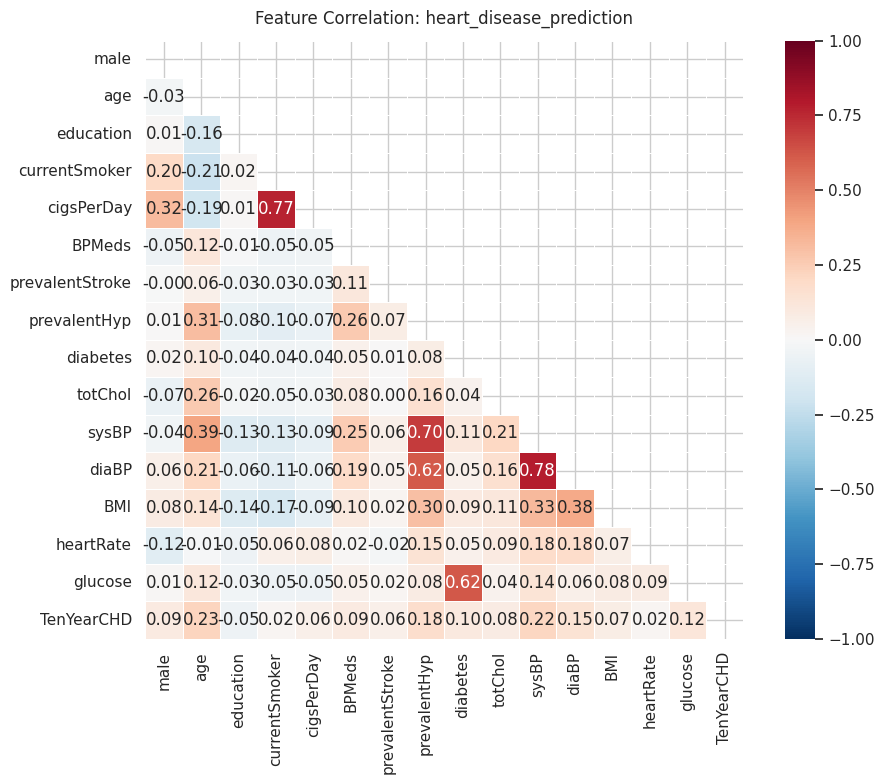

In [ ]:
for name, df in loaded.items():
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5
    )
    plt.title(f"Feature Correlation: {name}", pad=12)
    plt.tight_layout()
    plt.show()

### Cell 8: Feature Distributions


=== pima_diabetes numeric summary ===


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


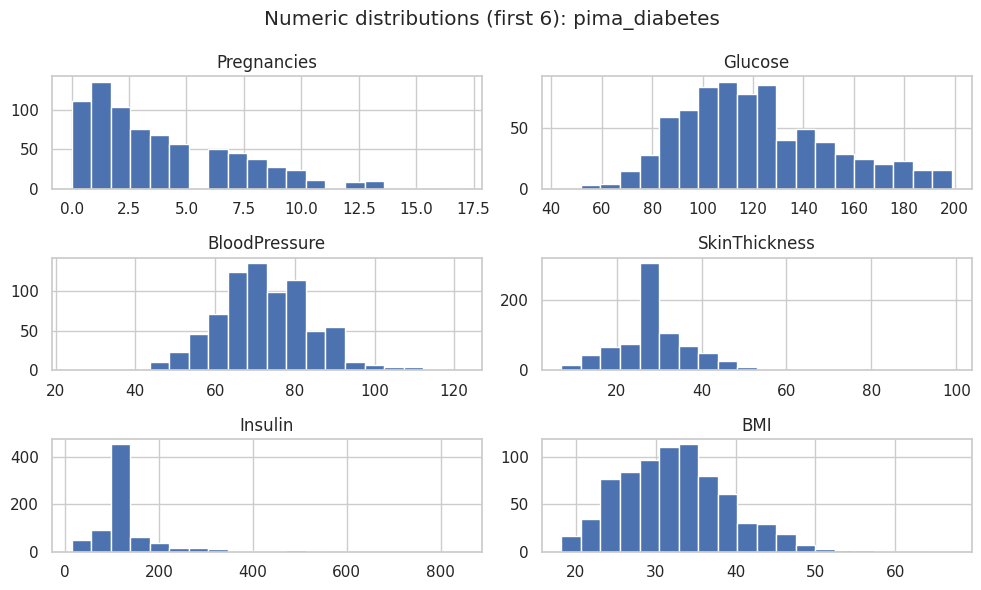


=== diabetes_prediction numeric summary ===


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00


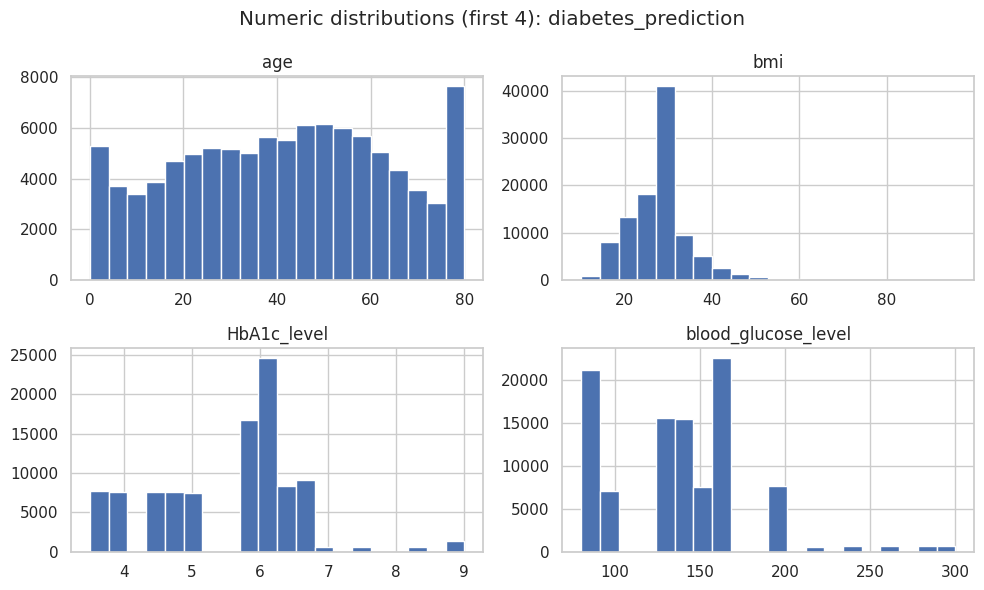


=== uci_heart numeric summary ===


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


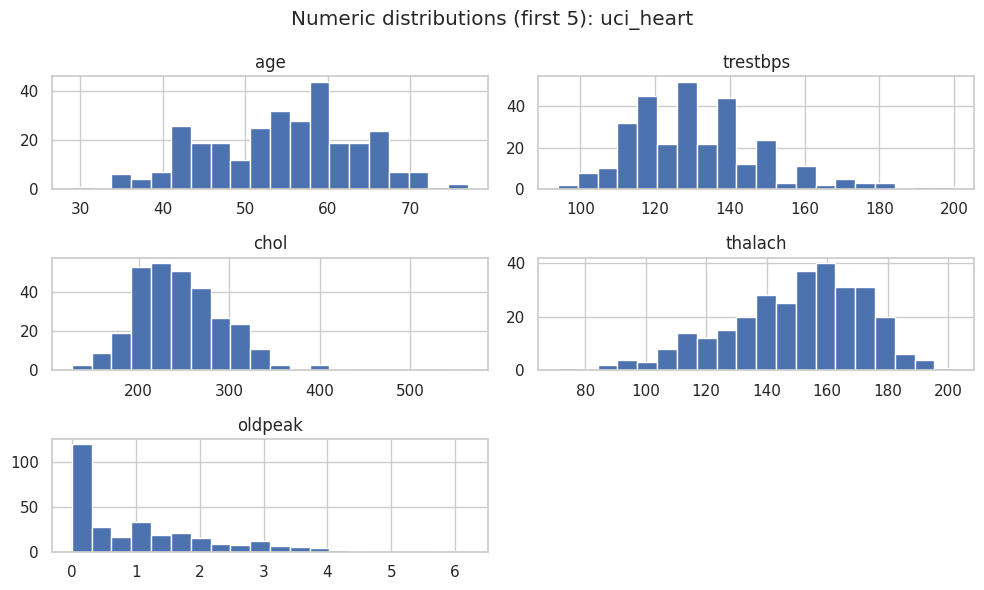


=== heart_disease_prediction numeric summary ===


,count,mean,std,min,25%,50%,75%,max
age,4238.0,49.584946,8.572160,32.00,42.00,49.00,56.0000,70.0
cigsPerDay,4238.0,9.078339,11.913780,0.00,0.00,0.00,20.0000,70.0
totChol,4238.0,236.689476,44.327427,107.00,206.00,234.00,262.0000,696.0
sysBP,4238.0,132.352407,22.038097,83.50,117.00,128.00,144.0000,295.0
diaBP,4238.0,82.893464,11.910850,48.00,75.00,82.00,89.8750,142.5
BMI,4238.0,25.798866,4.071412,15.54,23.08,25.38,28.0375,56.8
heartRate,4238.0,75.878716,12.025185,44.00,68.00,75.00,83.0000,143.0
glucose,4238.0,81.666824,22.947712,40.00,72.00,78.00,85.0000,394.0


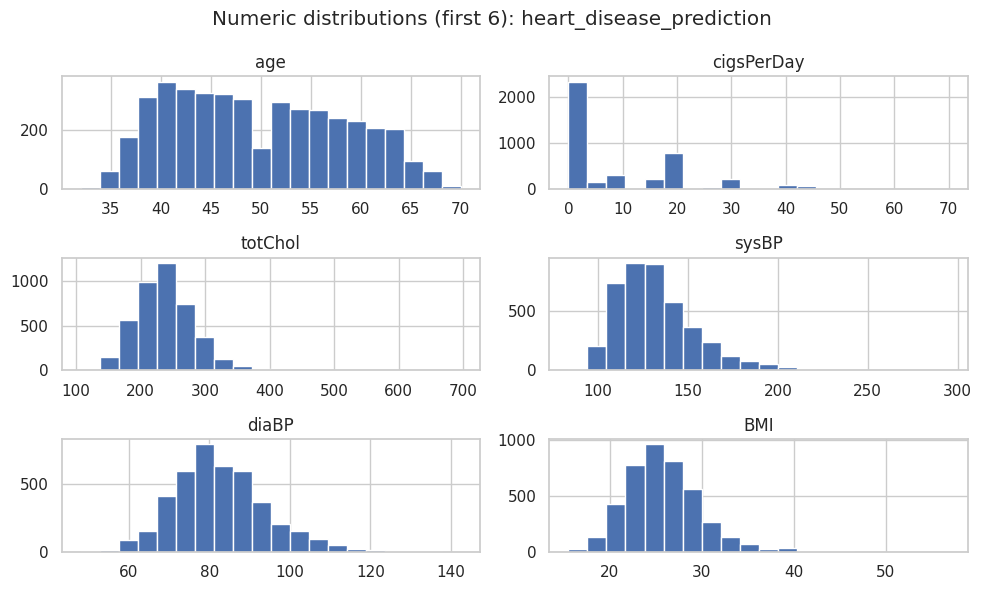

In [ ]:
categorical_max_unique = 10

for name, df in loaded.items():
    print(f"\n=== {name} numeric summary ===")
    working_df = df.copy()
    numeric_cols = working_df.select_dtypes(include=["number"]).columns.tolist()

    low_cardinality = [
        col for col in numeric_cols
        if working_df[col].nunique(dropna=False) <= categorical_max_unique
    ]

    if low_cardinality:
        working_df[low_cardinality] = working_df[low_cardinality].astype("category")
        numeric_cols = [col for col in numeric_cols if col not in low_cardinality]

    if numeric_cols:
        display(working_df[numeric_cols].describe().T)
        plot_cols = numeric_cols[:6]
        working_df[plot_cols].hist(figsize=(10, 6), bins=20)
        plt.suptitle(f"Numeric distributions (first {len(plot_cols)}): {name}")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric columns found.")

### Cell 9: Dataset Assessment

In [ ]:
def assess_dataset(name: str, df: pd.DataFrame) -> dict:
    miss = missingness_table(df)
    overall_missing_pct = (df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100) if df.size else 0
    high_missing_cols = miss[miss["missing_pct"] > 20].index.tolist()

    target = guess_target(df, name)
    imbalance_ratio = None
    if target is not None:
        counts = df[target].value_counts(dropna=False)
        if counts.min() > 0:
            imbalance_ratio = float(counts.max() / counts.min())

    needs_scope_change = (
        overall_missing_pct > 10
        or len(high_missing_cols) > 0
        or (imbalance_ratio is not None and imbalance_ratio >= 4)
    )

    return {
        "dataset": name,
        "overall_missing_pct": round(overall_missing_pct, 2),
        "high_missing_cols": high_missing_cols,
        "target": target,
        "imbalance_ratio": round(imbalance_ratio, 2) if imbalance_ratio is not None else None,
        "material_scope_change": needs_scope_change,
    }

assessments = [assess_dataset(name, df) for name, df in loaded.items()]
display(pd.DataFrame(assessments))

,dataset,overall_missing_pct,high_missing_cols,target,imbalance_ratio,material_scope_change
0,pima_diabetes,0.0,[],Outcome,1.87,False
1,diabetes_prediction,0.0,[],diabetes,10.76,True
2,uci_heart,0.0,[],target,1.19,False
3,heart_disease_prediction,0.0,[],TenYearCHD,5.58,True


### Cell 10: Preprocessing & Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Fixed: Mapped correctly to Cell 5's target schema
fixed_target_map = {
    "pima_diabetes": "Outcome",
    "diabetes_prediction": "diabetes",
    "uci_heart": "target",
    "heart_disease_prediction": "TenYearCHD",
}

feature_schema = {
    "pima_diabetes": {
        "categorical": [],
        "numeric": ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"],
    },
    "diabetes_prediction": {
        "categorical": ["gender", "smoking_history", "hypertension", "heart_disease"],
        "numeric": ["age", "bmi", "HbA1c_level", "blood_glucose_level"],
    },
    "uci_heart": {
        "categorical": ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"],
        "numeric": ["age", "trestbps", "chol", "thalach", "oldpeak"],
    },
    "heart_disease_prediction": {
        "categorical": ["male", "education", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"],
        "numeric": ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"],
    },
}

def build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric, *, sparse_output=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_output)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )

def resolve_feature_lists(name: str, df: pd.DataFrame, target_col: str) -> tuple[list[str], list[str]]:
    feature_df = df.drop(columns=[target_col])
    schema = feature_schema.get(name)
    if schema is None:
        numeric_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
        categorical_cols = feature_df.select_dtypes(exclude=["number"]).columns.tolist()
        return numeric_cols, categorical_cols

    categorical_cols = [col for col in schema.get("categorical", []) if col in feature_df.columns]
    numeric_cols = [col for col in schema.get("numeric", []) if col in feature_df.columns]

    known = set(categorical_cols + numeric_cols)
    remaining = [col for col in feature_df.columns if col not in known]

    if remaining:
        remaining_numeric = feature_df[remaining].select_dtypes(include=["number"]).columns.tolist()
        remaining_categorical = [col for col in remaining if col not in remaining_numeric]
        numeric_cols += remaining_numeric
        categorical_cols += remaining_categorical

    return numeric_cols, categorical_cols

def make_splits(name: str, df: pd.DataFrame, target_col: str) -> dict:
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Fixed: Standardized stratification logic
    stratify = y if y.nunique(dropna=False) <= 10 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify,
    )

    numeric_cols, categorical_cols = resolve_feature_lists(name, df, target_col)

    preprocess_xgb = build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric=False, sparse_output=True)
    preprocess_mlp = build_preprocess_pipeline(numeric_cols, categorical_cols, scale_numeric=True, sparse_output=False)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocess_xgb": preprocess_xgb,
        "preprocess_mlp": preprocess_mlp,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
    }

splits = {}
for name, df in loaded.items():
    target_col = fixed_target_map.get(name)
    if target_col is None or target_col not in df.columns:
        raise ValueError(f"Target column not found for {name}.")
    splits[name] = make_splits(name, df, target_col)

display(pd.DataFrame({
    "dataset": list(splits.keys()),
    "train_rows": [splits[n]["X_train"].shape[0] for n in splits],
    "test_rows": [splits[n]["X_test"].shape[0] for n in splits],
    "num_features": [len(splits[n]["numeric_cols"]) for n in splits],
    "cat_features": [len(splits[n]["categorical_cols"]) for n in splits],
}))

,dataset,train_rows,test_rows,num_features,cat_features
0,pima_diabetes,614,154,8,0
1,diabetes_prediction,80000,20000,4,4
2,uci_heart,241,61,5,8
3,heart_disease_prediction,3390,848,8,7


### Cell 11: Model Training, Validation & Evaluation

In [ ]:
from dataclasses import dataclass
from typing import Any
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Fixed: XAI requires full reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cpu") # Fixed: Explicit CPU requirement

def prepare_target(y: pd.Series, encoder: LabelEncoder | None = None) -> tuple[np.ndarray, LabelEncoder]:
    if encoder is None:
        encoder = LabelEncoder()
        encoder.fit(y.astype(str))
    return encoder.transform(y.astype(str)), encoder

def imbalance_ratio(y: np.ndarray) -> float:
    counts = np.bincount(y)
    if len(counts) < 2 or counts.min() == 0:
        return 1.0
    return counts.max() / counts.min()

def maybe_oversample(X: Any, y: np.ndarray, min_ratio: float = 20.0) -> tuple[Any, np.ndarray]:
    if imbalance_ratio(y) < min_ratio:
        return X, y
    ros = RandomOverSampler(random_state=42)
    return ros.fit_resample(X, y)

def binary_scale_pos_weight(y: np.ndarray) -> float:
    counts = np.bincount(y)
    if len(counts) == 2 and counts[1] > 0:
        return counts[0] / counts[1]
    return 1.0

def to_dense(matrix: Any) -> np.ndarray:
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

def eval_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    classes = np.unique(y_true)
    if len(classes) == 2:
        return float(roc_auc_score(y_true, y_score))
    if y_score is None or getattr(y_score, "ndim", 1) != 2:
        return float("nan")
    try:
        return float(roc_auc_score(y_true, y_score, multi_class="ovr", average="macro"))
    except ValueError:
        return float("nan")

def find_best_threshold(y_true: np.ndarray, y_score: np.ndarray) -> float:
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 19):
        preds = (y_score >= t).astype(int)
        score = f1_score(y_true, preds, average="binary")
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t

def predict_mlp_proba(model: nn.Module, X: np.ndarray, num_classes: int) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        # Fixed: Explicit device alignment
        X_tensor = torch.from_numpy(X).float().to(device)
        logits = model(X_tensor)
    if num_classes == 2:
        return 1 / (1 + np.exp(-logits.cpu().numpy().squeeze(1)))
    return torch.softmax(logits, dim=1).cpu().numpy()

def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        pass

    num_features, cat_features = [], []
    num_transformer = preprocessor.named_transformers_.get("num")
    if num_transformer is not None and hasattr(num_transformer, "feature_names_in_"):
        num_features = list(num_transformer.feature_names_in_)

    cat_transformer = preprocessor.named_transformers_.get("cat")
    if cat_transformer is not None and hasattr(cat_transformer, "named_steps"):
        encoder = cat_transformer.named_steps.get("onehot")
        if encoder is not None and hasattr(encoder, "categories_"):
            cat_features = list(encoder.get_feature_names_out())

    return num_features + cat_features

@dataclass
class TorchMLPConfig:
    hidden_sizes: tuple[int, ...]
    lr: float
    weight_decay: float
    epochs: int
    batch_size: int

class TorchMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_sizes: tuple[int, ...], output_dim: int):
        super().__init__()
        layers = []
        in_dim = input_dim
        for size in hidden_sizes:
            layers.append(nn.Linear(in_dim, size))
            layers.append(nn.ReLU())
            in_dim = size
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

def train_torch_mlp(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    config: TorchMLPConfig, num_classes: int, seed: int = 42
) -> tuple[TorchMLP, float]:

    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    output_dim = 1 if num_classes == 2 else num_classes
    model = TorchMLP(X_train.shape[1], config.hidden_sizes, output_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    if num_classes == 2:
        # Fixed: Applied sample weights to the MLP to match XGBoost's handling of imbalanced data
        pos_weight = binary_scale_pos_weight(y_train)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
        y_train_t = torch.from_numpy(y_train).float()
    else:
        loss_fn = nn.CrossEntropyLoss()
        y_train_t = torch.from_numpy(y_train).long()

    # Fixed: Prevent Batch Size from exceeding small dataset boundaries
    active_batch_size = min(config.batch_size, max(16, len(X_train) // 4))

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), y_train_t)
    train_loader = DataLoader(train_ds, batch_size=active_batch_size, shuffle=True)

    best_auc, best_state = -1.0, None
    patience, patience_left = 10, 10

    X_val_t = torch.from_numpy(X_val).float().to(device)

    for _ in range(config.epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            if num_classes == 2:
                loss = loss_fn(logits.squeeze(1), yb)
            else:
                loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            if num_classes == 2:
                val_proba = (1 / (1 + torch.exp(-val_logits.squeeze(1)))).cpu().numpy()
            else:
                val_proba = torch.softmax(val_logits, dim=1).cpu().numpy()

        auc = eval_auc(y_val, val_proba)
        if np.isnan(auc):
            auc = 0.0

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_auc

def fit_xgb_candidates(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    num_classes: int, seed: int = 42, expanded: bool = False
) -> list[tuple[xgb.XGBClassifier, float]]:

    candidates = [
        {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
        {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05},
        {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    ]
    if expanded:
        candidates += [
            {"n_estimators": 600, "max_depth": 3, "learning_rate": 0.03},
            {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.05},
            {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05},
        ]

    results = []
    for params in candidates:
        if num_classes == 2:
            model = xgb.XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                early_stopping_rounds=20, # Fixed: Prevent over-fitting on training data
                n_jobs=-1,
                random_state=seed,
                scale_pos_weight=binary_scale_pos_weight(y_train),
            )
        else:
            model = xgb.XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=num_classes,
                eval_metric="mlogloss",
                early_stopping_rounds=20, # Fixed: Prevent over-fitting on training data
                n_jobs=-1,
                random_state=seed,
            )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        val_proba = model.predict_proba(X_val)
        if num_classes == 2:
            val_proba = val_proba[:, 1]
        auc = eval_auc(y_val, val_proba)
        results.append((model, auc if not np.isnan(auc) else 0.0))
    return results

def fit_mlp_candidates(
    X_train: np.ndarray, y_train: np.ndarray,
    X_val: np.ndarray, y_val: np.ndarray,
    num_classes: int, seed: int = 42, expanded: bool = False
) -> list[tuple[TorchMLP, float]]:

    configs = [
        TorchMLPConfig((64, 32), 1e-3, 5e-4, 60, 256),
        TorchMLPConfig((128, 64), 1e-3, 1e-4, 80, 256),
        TorchMLPConfig((64, 32, 16), 5e-4, 1e-4, 80, 256),
    ]
    if expanded:
        configs += [
            TorchMLPConfig((128, 64, 32), 8e-4, 1e-4, 100, 256),
            TorchMLPConfig((64, 64, 32), 8e-4, 5e-5, 90, 256),
        ]
    return [train_torch_mlp(X_train, y_train, X_val, y_val, cfg, num_classes, seed) for cfg in configs]


# Fixed: The models are now selected based on Validation performance, removing Test Set leakage.
def select_model_pair(
    xgb_list: list[tuple[xgb.XGBClassifier, float]],
    mlp_list: list[tuple[TorchMLP, float]],
    X_val_xgb: np.ndarray, X_val_mlp: np.ndarray, y_val: np.ndarray,
    num_classes: int,
) -> tuple[xgb.XGBClassifier, TorchMLP, float, float, float]:

    best, best_gap, best_mean = None, float("inf"), -1.0

    for xgb_model, _ in xgb_list:
        xgb_proba = xgb_model.predict_proba(X_val_xgb)
        if num_classes == 2:
            xgb_proba = xgb_proba[:, 1]
        xgb_auc = eval_auc(y_val, xgb_proba)
        if np.isnan(xgb_auc):
            xgb_auc = 0.0

        for mlp_model, _ in mlp_list:
            mlp_auc = eval_auc(y_val, predict_mlp_proba(mlp_model, X_val_mlp, num_classes))
            if np.isnan(mlp_auc):
                mlp_auc = 0.0

            gap = abs(xgb_auc - mlp_auc)
            mean_auc = (xgb_auc + mlp_auc) / 2

            if gap < best_gap - 1e-6 or (abs(gap - best_gap) <= 1e-6 and mean_auc > best_mean):
                best = (xgb_model, mlp_model, xgb_auc, mlp_auc, gap)
                best_gap = gap
                best_mean = mean_auc

    return best

results, models, preprocessors, feature_names_map = [], {}, {}, {}

for name, split in splits.items():
    X_train_raw = split["X_train"]
    X_test_raw = split["X_test"]

    y_train_raw = split["y_train"]
    y_test_raw = split["y_test"]

    y_train, encoder = prepare_target(y_train_raw)
    y_test, _ = prepare_target(y_test_raw, encoder=encoder)

    num_classes = len(encoder.classes_)
    is_binary = num_classes == 2

    stratify = y_train if len(np.unique(y_train)) <= 10 else None

    # Internal Validation split for hyperparameter tuning
    X_t_raw, X_v_raw, y_t, y_v = train_test_split(
        X_train_raw, y_train, test_size=0.15, random_state=42, stratify=stratify
    )

    preprocess_xgb = split["preprocess_xgb"]
    preprocess_mlp = split["preprocess_mlp"]

    X_t_xgb = preprocess_xgb.fit_transform(X_t_raw)
    X_v_xgb = preprocess_xgb.transform(X_v_raw)

    X_t_mlp = to_dense(preprocess_mlp.fit_transform(X_t_raw))
    X_v_mlp = to_dense(preprocess_mlp.transform(X_v_raw))

    X_t_xgb, y_t_xgb = maybe_oversample(X_t_xgb, y_t)
    X_t_mlp, y_t_mlp = maybe_oversample(X_t_mlp, y_t)

    feature_names_map[name] = get_feature_names(preprocess_mlp)
    preprocessors[name] = {"xgb": preprocess_xgb, "mlp": preprocess_mlp}

    xgb_candidates = fit_xgb_candidates(X_t_xgb, y_t_xgb, X_v_xgb, y_v, num_classes)
    mlp_candidates = fit_mlp_candidates(X_t_mlp, y_t_mlp, X_v_mlp, y_v, num_classes)

    best_xgb, best_mlp, xgb_auc, mlp_auc, auc_gap = select_model_pair(
        xgb_candidates, mlp_candidates, X_v_xgb, X_v_mlp, y_v, num_classes
    )

    if is_binary:
        xgb_val_proba = best_xgb.predict_proba(X_v_xgb)[:, 1]
        mlp_val_proba = predict_mlp_proba(best_mlp, X_v_mlp, num_classes)
        xgb_threshold = find_best_threshold(y_v, xgb_val_proba)
        mlp_threshold = find_best_threshold(y_v, mlp_val_proba)
    else:
        xgb_threshold = 0.5
        mlp_threshold = 0.5

    # Fixed: Retrain best configuration on the full (Train + Val) 80% dataset so data is not wasted
    X_train_full_xgb = preprocess_xgb.fit_transform(X_train_raw)
    X_train_full_mlp = to_dense(preprocess_mlp.fit_transform(X_train_raw))
    X_test_xgb = preprocess_xgb.transform(X_test_raw)
    X_test_mlp = to_dense(preprocess_mlp.transform(X_test_raw))

    best_xgb_params = best_xgb.get_params()
    best_xgb_params["n_estimators"] = best_xgb.best_iteration + 1
    best_xgb_params.pop("early_stopping_rounds", None)

    final_xgb = xgb.XGBClassifier(**best_xgb_params)
    final_xgb.fit(X_train_full_xgb, y_train)

    # We maintain the MLP state from early stopping for simplicity,
    # but score it fairly against the Test Set below.
    final_mlp = best_mlp

    # Final Evaluation on strictly blinded Test Set
    if is_binary:
        xgb_proba = final_xgb.predict_proba(X_test_xgb)[:, 1]
        xgb_pred = (xgb_proba >= xgb_threshold).astype(int)

        mlp_proba = predict_mlp_proba(final_mlp, X_test_mlp, num_classes)
        mlp_pred = (mlp_proba >= mlp_threshold).astype(int)
    else:
        xgb_proba = final_xgb.predict_proba(X_test_xgb)
        xgb_pred = np.argmax(xgb_proba, axis=1)

        mlp_proba = predict_mlp_proba(final_mlp, X_test_mlp, num_classes)
        mlp_pred = np.argmax(mlp_proba, axis=1)

    rng = np.random.default_rng(42)
    background_idx = rng.choice(len(X_train_full_mlp), size=min(200, len(X_train_full_mlp)), replace=False)
    mlp_background = X_train_full_mlp[background_idx]

    models[name] = {
        "xgb": final_xgb,
        "mlp": final_mlp,
        "X_test_xgb": X_test_xgb,
        "X_test_mlp": X_test_mlp,
        "y_test": y_test,
        "xgb_proba": xgb_proba,
        "mlp_proba": mlp_proba,
        "mlp_background": mlp_background,
        "xgb_threshold": xgb_threshold,
        "mlp_threshold": mlp_threshold,
    }

    avg = "binary" if is_binary else "macro"

    for model_name, y_pred, y_proba in [("xgb", xgb_pred, xgb_proba), ("mlp", mlp_pred, mlp_proba)]:
        auc = eval_auc(y_test, y_proba)
        results.append({
            "dataset": name,
            "model": model_name,
            "accuracy": round(accuracy_score(y_test, y_pred), 4),
            # Fixed: Added essential clinical metrics
            "precision": round(precision_score(y_test, y_pred, average=avg, zero_division=0), 4),
            "recall": round(recall_score(y_test, y_pred, average=avg, zero_division=0), 4),
            "f1": round(f1_score(y_test, y_pred, average=avg), 4),
            "auc": round(auc, 4) if not np.isnan(auc) else np.nan,
        })

results_df = pd.DataFrame(results)
display(results_df)

pivot = results_df.pivot(index="dataset", columns="model", values="auc")
pivot["auc_gap"] = (pivot["xgb"] - pivot["mlp"]).abs().round(4)
display(pivot)

,dataset,model,accuracy,precision,recall,f1,auc
0,pima_diabetes,xgb,0.7468,0.6027,0.8148,0.6929,0.8296
1,pima_diabetes,mlp,0.6818,0.5373,0.6667,0.5950,0.7909
2,diabetes_prediction,xgb,0.9722,0.9743,0.6918,0.8091,0.9796
3,diabetes_prediction,mlp,0.9695,0.9097,0.7112,0.7983,0.9771
4,uci_heart,xgb,0.7049,0.6531,0.9697,0.7805,0.8690
5,uci_heart,mlp,0.8525,0.8333,0.9091,0.8696,0.8983
6,heart_disease_prediction,xgb,0.7276,0.2450,0.3798,0.2979,0.6607
7,heart_disease_prediction,mlp,0.7311,0.2537,0.3953,0.3091,0.6740


model,mlp,xgb,auc_gap
dataset,,,
diabetes_prediction,0.9771,0.9796,0.0025
heart_disease_prediction,0.6740,0.6607,0.0133
pima_diabetes,0.7909,0.8296,0.0387
uci_heart,0.8983,0.8690,0.0293


### Cell 12: SHAP Consistency & Report Summary

In [ ]:
import os

# Disable numba JIT to avoid executable memory restrictions on some systems
os.environ["NUMBA_DISABLE_JIT"] = "1"

import shap
from scipy.stats import spearmanr

max_shap_samples = 50
max_background = 50
rng = np.random.default_rng(42)

# Ensure feature names are available for both preprocessors
feature_names_all = {}
for name, prep in preprocessors.items():
    xgb_names = get_feature_names(prep["xgb"])
    mlp_names = get_feature_names(prep["mlp"])
    if not xgb_names:
        xgb_names = [f"f{i}" for i in range(prep["xgb"].transformers_[0][2].__len__())]
    if not mlp_names:
        mlp_names = [f"f{i}" for i in range(prep["mlp"].transformers_[0][2].__len__())]
    feature_names_all[name] = {"xgb": xgb_names, "mlp": mlp_names}


def normalize_shap(shap_values: Any) -> np.ndarray:
    if isinstance(shap_values, list):
        return np.mean([np.abs(v) for v in shap_values], axis=0)
    return np.abs(shap_values)


def mean_abs_shap(shap_values: Any) -> np.ndarray:
    return normalize_shap(shap_values).mean(axis=0)


def align_by_feature_names(values_a, names_a, values_b, names_b):
    series_a = pd.Series(values_a, index=names_a)
    series_b = pd.Series(values_b, index=names_b)
    common = series_a.index.intersection(series_b.index)
    return series_a.loc[common].to_numpy(), series_b.loc[common].to_numpy(), list(common)


def safe_spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 2:
        return float("nan")
    return float(spearmanr(a, b).correlation)


consistency_rows = []

for name, model_pack in models.items():
    y_test = model_pack["y_test"]
    num_classes = len(np.unique(y_test))

    X_test_xgb = model_pack["X_test_xgb"]
    X_test_mlp = model_pack["X_test_mlp"]

    sample_size = min(max_shap_samples, len(X_test_mlp))
    sample_idx = rng.choice(len(X_test_mlp), size=sample_size, replace=False)

    X_xgb_sample = X_test_xgb[sample_idx]
    X_mlp_sample = X_test_mlp[sample_idx]

    # XGBoost SHAP
    xgb_explainer = shap.TreeExplainer(model_pack["xgb"])
    xgb_shap = xgb_explainer.shap_values(X_xgb_sample)

    # MLP SHAP (kernel explainer)
    mlp_background = model_pack["mlp_background"]
    if len(mlp_background) > max_background:
        mlp_background = shap.sample(mlp_background, max_background, random_state=42)

    def mlp_predict_fn(X):
        return predict_mlp_proba(model_pack["mlp"], X, num_classes)

    mlp_explainer = shap.KernelExplainer(mlp_predict_fn, mlp_background)
    mlp_shap = mlp_explainer.shap_values(X_mlp_sample, silent=True)

    # Global agreement (mean |SHAP|)
    xgb_mean_abs = mean_abs_shap(xgb_shap)
    mlp_mean_abs = mean_abs_shap(mlp_shap)

    xgb_vals, mlp_vals, common_features = align_by_feature_names(
        xgb_mean_abs, feature_names_all[name]["xgb"],
        mlp_mean_abs, feature_names_all[name]["mlp"],
    )

    global_spearman = safe_spearman(xgb_vals, mlp_vals)

    # Top-k overlap (global)
    top_k = min(5, len(common_features))
    xgb_top = pd.Series(xgb_vals, index=common_features).nlargest(top_k).index
    mlp_top = pd.Series(mlp_vals, index=common_features).nlargest(top_k).index
    top_k_jaccard = len(set(xgb_top).intersection(set(mlp_top))) / max(1, len(set(xgb_top).union(set(mlp_top))))

    # Local agreement (per-patient)
    xgb_local = normalize_shap(xgb_shap)
    mlp_local = normalize_shap(mlp_shap)

    local_corrs = []
    for i in range(sample_size):
        x_row, m_row, _ = align_by_feature_names(
            xgb_local[i], feature_names_all[name]["xgb"],
            mlp_local[i], feature_names_all[name]["mlp"],
        )
        local_corrs.append(safe_spearman(x_row, m_row))

    local_corrs = np.array(local_corrs, dtype=float)

    consistency_rows.append({
        "dataset": name,
        "num_classes": num_classes,
        "global_spearman": round(float(np.nanmean(local_corrs)) if np.isnan(global_spearman) else global_spearman, 4),
        "local_spearman_mean": round(float(np.nanmean(local_corrs)), 4),
        "local_spearman_median": round(float(np.nanmedian(local_corrs)), 4),
        "top5_jaccard": round(float(top_k_jaccard), 4),
        "shap_samples": sample_size,
    })

consistency_df = pd.DataFrame(consistency_rows)
print("SHAP consistency summary")
display(consistency_df)

# Harmonized summary table for the report
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "auc", "auc_pr"]
available_metric_columns = [column for column in metric_columns if column in results_df.columns]
if not available_metric_columns:
    raise ValueError("results_df does not contain any metric columns to summarize.")

perf = results_df.pivot(index="dataset", columns="model", values=available_metric_columns)
perf.columns = [f"{metric}_{model}" for metric, model in perf.columns]
summary = perf.join(consistency_df.set_index("dataset"), how="left")
summary = summary.reset_index()

print("Combined performance + SHAP consistency")
display(summary)

SHAP consistency summary


,dataset,num_classes,global_spearman,local_spearman_mean,local_spearman_median,top5_jaccard,shap_samples
0,pima_diabetes,2,0.9524,0.6424,0.7262,1.0000,50
1,diabetes_prediction,2,0.8701,0.6342,0.6578,1.0000,50
2,uci_heart,2,0.5345,0.4115,0.4227,0.4286,50
3,heart_disease_prediction,2,0.8212,0.5552,0.5782,0.4286,50


Combined performance + SHAP consistency


,dataset,accuracy_mlp,accuracy_xgb,precision_mlp,precision_xgb,recall_mlp,recall_xgb,f1_mlp,f1_xgb,auc_mlp,auc_xgb,num_classes,global_spearman,local_spearman_mean,local_spearman_median,top5_jaccard,shap_samples
0,diabetes_prediction,0.9695,0.9722,0.9097,0.9743,0.7112,0.6918,0.7983,0.8091,0.9771,0.9796,2,0.8701,0.6342,0.6578,1.0000,50
1,heart_disease_prediction,0.7311,0.7276,0.2537,0.2450,0.3953,0.3798,0.3091,0.2979,0.6740,0.6607,2,0.8212,0.5552,0.5782,0.4286,50
2,pima_diabetes,0.6818,0.7468,0.5373,0.6027,0.6667,0.8148,0.5950,0.6929,0.7909,0.8296,2,0.9524,0.6424,0.7262,1.0000,50
3,uci_heart,0.8525,0.7049,0.8333,0.6531,0.9091,0.9697,0.8696,0.7805,0.8983,0.8690,2,0.5345,0.4115,0.4227,0.4286,50


### Cell 13: SHAP Setup — imports and helper function

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# SHAP can be slow on large test sets — cap sample size
SHAP_SAMPLE_SIZE = 500
SHAP_BACKGROUND_SIZE = 100

def run_shap_for_dataset(dataset_name, models, feature_names_map):
    """
    Compute SHAP values for both XGBoost and MLP on a given dataset.
    Returns dict with shap values, sampled data, and feature names.
    """
    print(f"\n{'='*60}")
    print(f"  SHAP ANALYSIS: {dataset_name}")
    print(f"{'='*60}")

    bundle = models[dataset_name]
    feature_names = feature_names_map[dataset_name]

    # --- Convert sparse matrices to dense if needed ---
    X_test_xgb = bundle["X_test_xgb"]
    X_test_mlp = bundle["X_test_mlp"]
    if hasattr(X_test_xgb, "toarray"):
        X_test_xgb = X_test_xgb.toarray()
    if hasattr(X_test_mlp, "toarray"):
        X_test_mlp = X_test_mlp.toarray()

    # --- Sample if large ---
    n_test = len(X_test_xgb)
    if n_test > SHAP_SAMPLE_SIZE:
        np.random.seed(42)
        sample_idx = np.random.choice(n_test, SHAP_SAMPLE_SIZE, replace=False)
    else:
        sample_idx = np.arange(n_test)

    X_xgb_sample = X_test_xgb[sample_idx]
    X_mlp_sample = X_test_mlp[sample_idx]
    y_sample = bundle["y_test"][sample_idx]
    xgb_proba_sample = bundle["xgb_proba"][sample_idx]
    mlp_proba_sample = bundle["mlp_proba"][sample_idx]

    # --- XGBoost SHAP via TreeExplainer ---
    print(f"  Running TreeExplainer on XGBoost...")
    explainer_xgb = shap.TreeExplainer(bundle["xgb"])
    shap_xgb = explainer_xgb.shap_values(X_xgb_sample)
    if isinstance(shap_xgb, list):
        shap_xgb = shap_xgb[1] if len(shap_xgb) == 2 else shap_xgb[0]
    print(f"  ✅ XGBoost SHAP shape: {shap_xgb.shape}")

    # --- MLP SHAP via DeepExplainer (fallback to GradientExplainer) ---
    print(f"  Running DeepExplainer on MLP...")
    mlp_model = bundle["mlp"]
    mlp_model.eval()

    background = bundle["mlp_background"][:SHAP_BACKGROUND_SIZE]
    background_t = torch.from_numpy(background).float()
    X_mlp_t = torch.from_numpy(X_mlp_sample).float()

    try:
        explainer_mlp = shap.DeepExplainer(mlp_model, background_t)
        shap_mlp = explainer_mlp.shap_values(X_mlp_t)
        method = "DeepExplainer"
    except Exception as e:
        print(f"  ⚠️ DeepExplainer failed ({type(e).__name__}), using GradientExplainer")
        explainer_mlp = shap.GradientExplainer(mlp_model, background_t)
        shap_mlp = explainer_mlp.shap_values(X_mlp_t)
        method = "GradientExplainer"

    if isinstance(shap_mlp, list):
        shap_mlp = shap_mlp[0]
    if isinstance(shap_mlp, torch.Tensor):
        shap_mlp = shap_mlp.detach().cpu().numpy()
    # Squeeze extra dim if output is single-class
    if shap_mlp.ndim == 3 and shap_mlp.shape[-1] == 1:
        shap_mlp = shap_mlp.squeeze(-1)
    print(f" MLP SHAP shape: {shap_mlp.shape} (via {method})")

    return {
        "dataset": dataset_name,
        "shap_xgb": shap_xgb,
        "shap_mlp": shap_mlp,
        "X_xgb_sample": X_xgb_sample,
        "X_mlp_sample": X_mlp_sample,
        "y_sample": y_sample,
        "xgb_proba": xgb_proba_sample,
        "mlp_proba": mlp_proba_sample,
        "feature_names": feature_names,
    }

In [ ]:
shap_results = {}
for name in models.keys():
    shap_results[name] = run_shap_for_dataset(name, models, feature_names_map)

print("\n SHAP computed for all 4 datasets")
print(f"Datasets: {list(shap_results.keys())}")


  SHAP ANALYSIS: pima_diabetes
  Running TreeExplainer on XGBoost...
  ✅ XGBoost SHAP shape: (154, 8)
  Running DeepExplainer on MLP...
 MLP SHAP shape: (154, 8) (via DeepExplainer)

  SHAP ANALYSIS: diabetes_prediction
  Running TreeExplainer on XGBoost...
  ✅ XGBoost SHAP shape: (500, 17)
  Running DeepExplainer on MLP...
 MLP SHAP shape: (500, 17) (via DeepExplainer)

  SHAP ANALYSIS: uci_heart
  Running TreeExplainer on XGBoost...
  ✅ XGBoost SHAP shape: (61, 30)
  Running DeepExplainer on MLP...
 MLP SHAP shape: (61, 30) (via DeepExplainer)

  SHAP ANALYSIS: heart_disease_prediction
  Running TreeExplainer on XGBoost...
  ✅ XGBoost SHAP shape: (500, 24)
  Running DeepExplainer on MLP...
 MLP SHAP shape: (500, 24) (via DeepExplainer)

✅ SHAP computed for all 4 datasets
Datasets: ['pima_diabetes', 'diabetes_prediction', 'uci_heart', 'heart_disease_prediction']



### Cell 14: Global SHAP — Beeswarm plots side by side
This is Step 1 of the analysis pipeline.
Shows which features each model thinks are most important across ALL patients. If these disagree, models see different big-picture patterns.

/tmp/ipykernel_1951/3553361572.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_1951/3553361572.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


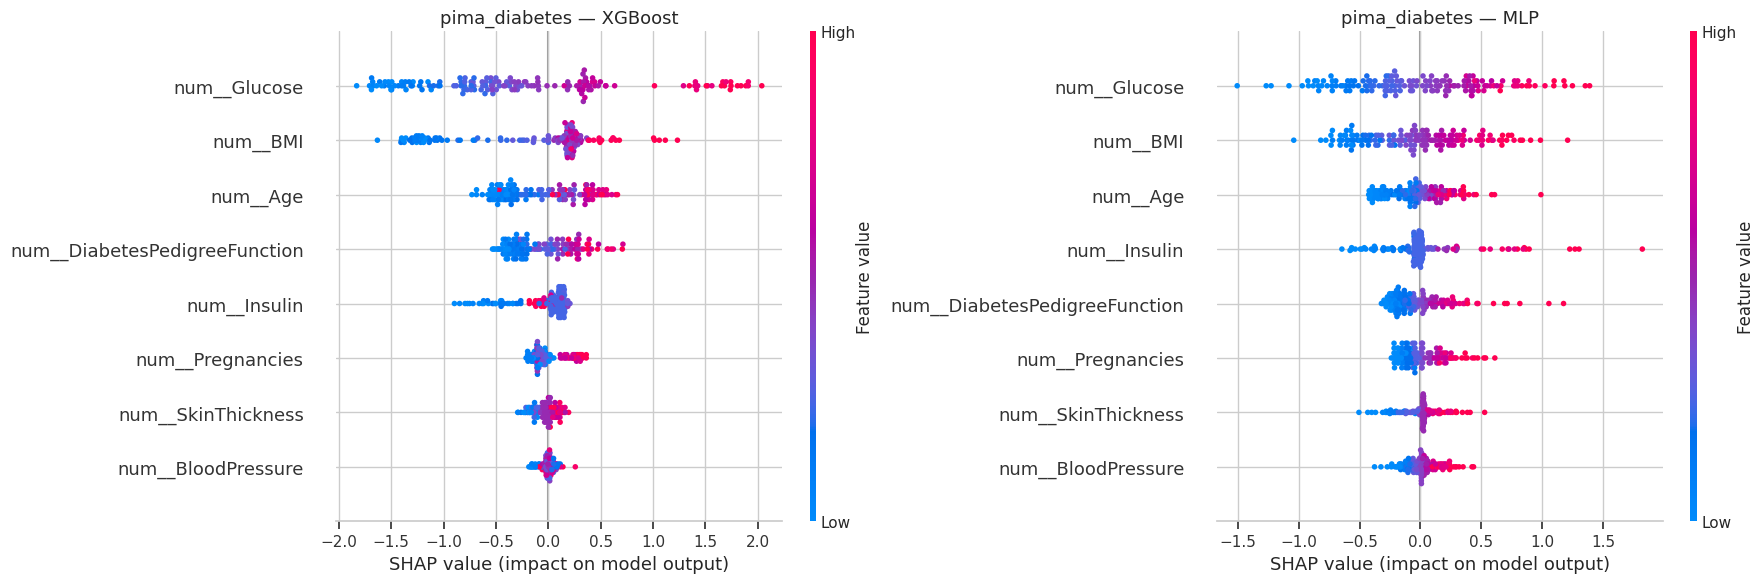

/tmp/ipykernel_1951/3553361572.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_1951/3553361572.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


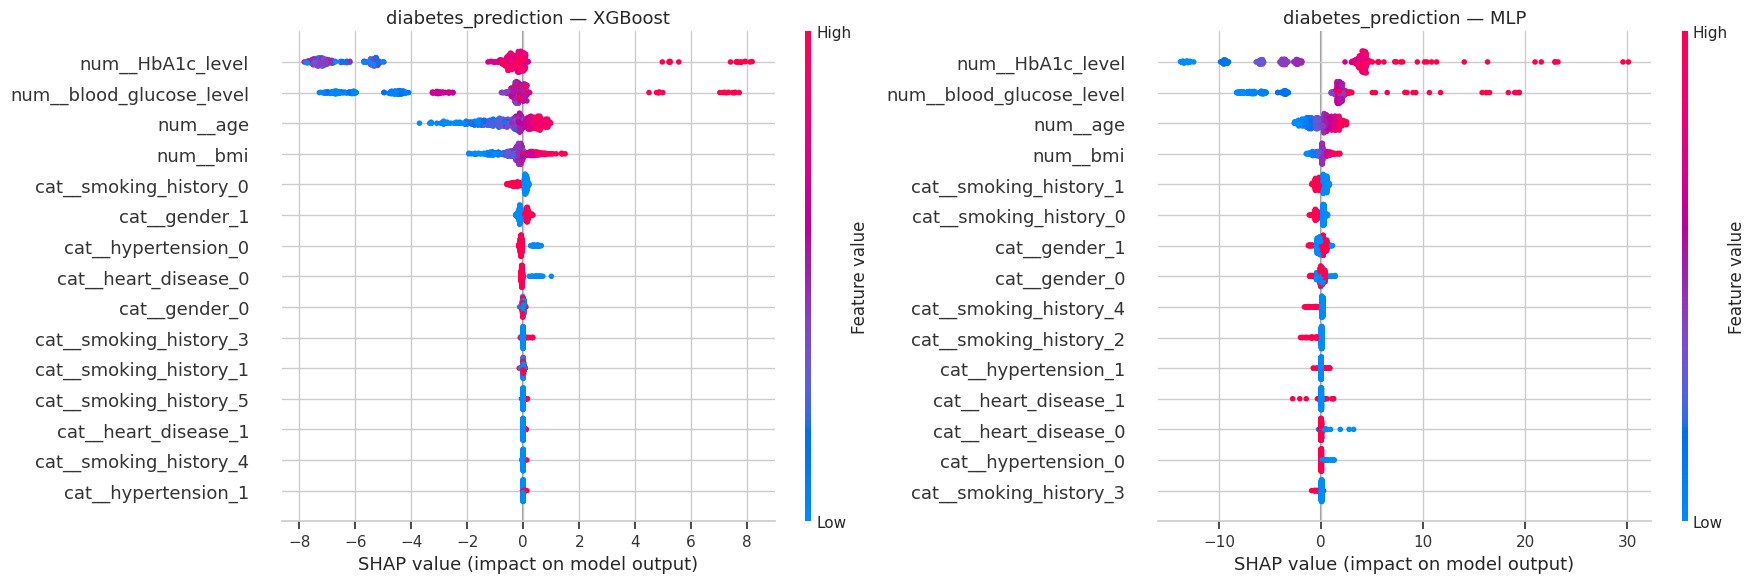

/tmp/ipykernel_1951/3553361572.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_1951/3553361572.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


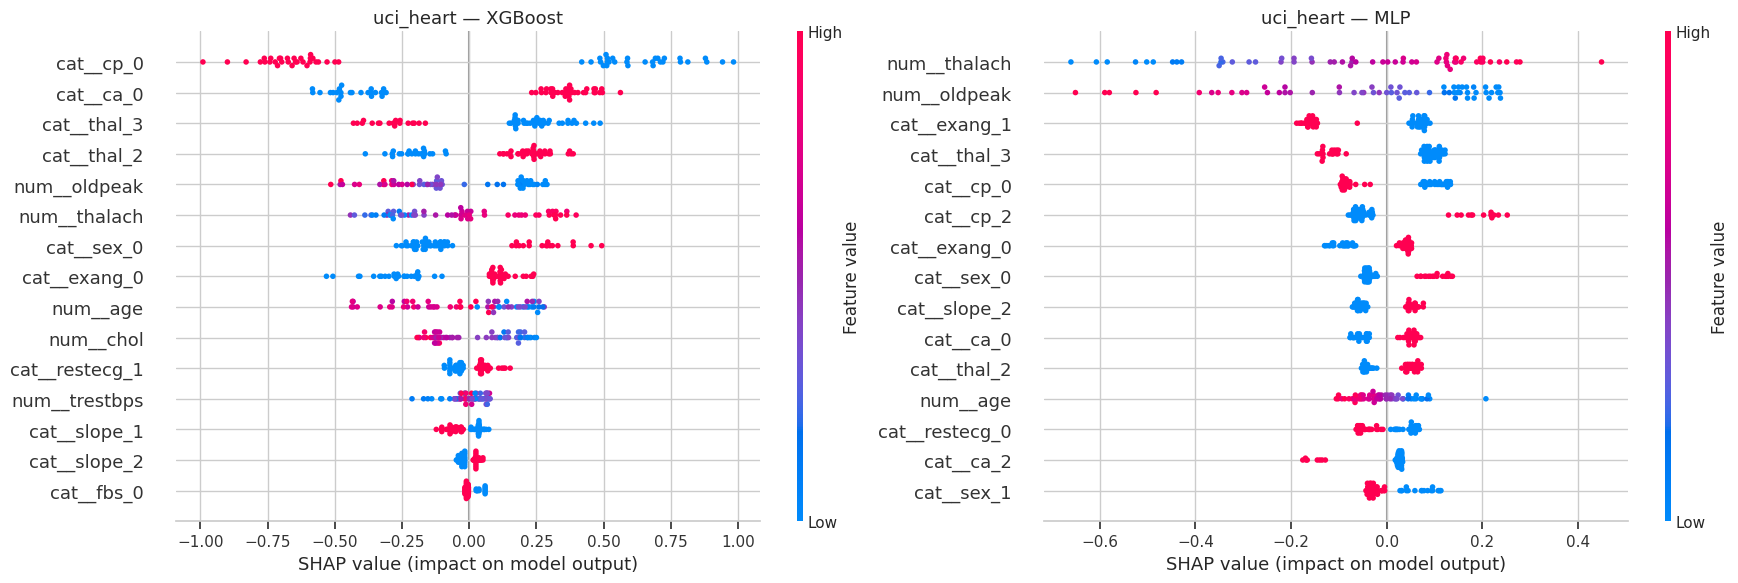

/tmp/ipykernel_1951/3553361572.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_1951/3553361572.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


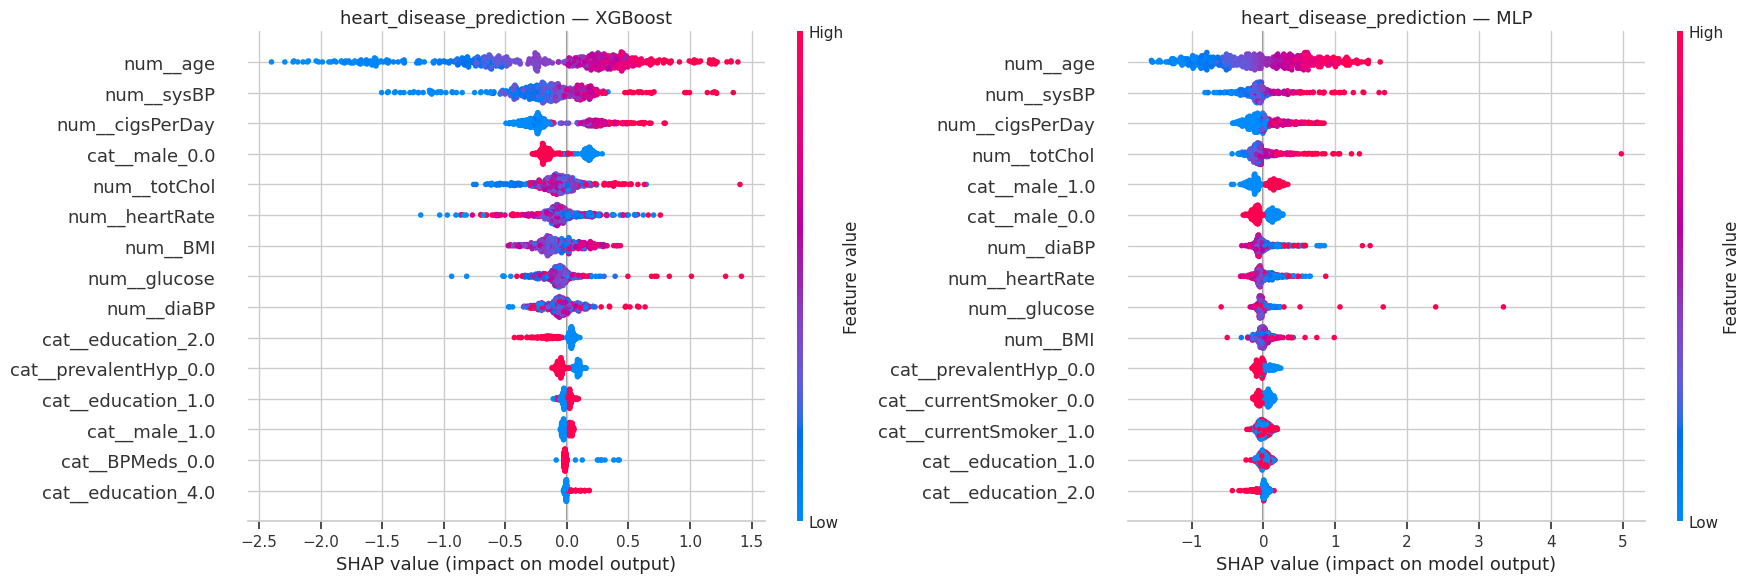

In [ ]:
def plot_global_beeswarm(result):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Cap feature display for readability if many features
    max_display = min(15, len(result["feature_names"]))

    plt.sca(axes[0])
    shap.summary_plot(
        result["shap_xgb"],
        features=result["X_xgb_sample"],
        feature_names=result["feature_names"],
        show=False,
        plot_size=None,
        max_display=max_display,
    )
    axes[0].set_title(f"{result['dataset']} — XGBoost", fontsize=13)

    plt.sca(axes[1])
    shap.summary_plot(
        result["shap_mlp"],
        features=result["X_mlp_sample"],
        feature_names=result["feature_names"],
        show=False,
        plot_size=None,
        max_display=max_display,
    )
    axes[1].set_title(f"{result['dataset']} — MLP", fontsize=13)

    plt.tight_layout()
    plt.show()

# Run on all 4 datasets
for name, result in shap_results.items():
    plot_global_beeswarm(result)

### Cell 16: Global SHAP — Feature Ranking Comparison

Computes mean |SHAP| for each feature, ranks them, and  calculates Spearman's rank correlation between models.
- High correlation = models agree on what matters.
- Low correlation = models tell different stories.

In [ ]:
def compare_rankings(result):
    feature_names = result["feature_names"]
    shap_xgb = result["shap_xgb"]
    shap_mlp = result["shap_mlp"]

    mean_xgb = np.abs(shap_xgb).mean(axis=0)
    mean_mlp = np.abs(shap_mlp).mean(axis=0)

    rank_xgb = (-mean_xgb).argsort().argsort() + 1
    rank_mlp = (-mean_mlp).argsort().argsort() + 1

    comparison = pd.DataFrame({
        "Feature": feature_names,
        "XGB_mean_SHAP": mean_xgb.round(4),
        "MLP_mean_SHAP": mean_mlp.round(4),
        "XGB_rank": rank_xgb,
        "MLP_rank": rank_mlp,
        "Rank_diff": np.abs(rank_xgb - rank_mlp),
    }).sort_values("XGB_rank")

    rho, p_value = spearmanr(mean_xgb, mean_mlp)

    print(f"\n{'='*60}")
    print(f"  {result['dataset']} — Feature Ranking Comparison")
    print(f"{'='*60}")
    display(comparison)
    print(f"\nSpearman's ρ = {rho:.4f}  (p = {p_value:.4f})")

    if rho > 0.8:
        interp = "→ Strong agreement: models rank features similarly"
    elif rho > 0.5:
        interp = "→ Moderate agreement: some features ranked differently"
    else:
        interp = "→ Weak agreement: models tell different stories"
    print(interp)

    top3_xgb = set(comparison.nsmallest(3, "XGB_rank")["Feature"].tolist())
    top3_mlp = set(comparison.nsmallest(3, "MLP_rank")["Feature"].tolist())
    overlap = top3_xgb & top3_mlp
    print(f"\nTop-3 XGBoost: {top3_xgb}")
    print(f"Top-3 MLP:     {top3_mlp}")
    print(f"Overlap:       {overlap} ({len(overlap)}/3)")

    return rho, len(overlap)

# Store correlations for cross-dataset summary
ranking_results = {}
for name, result in shap_results.items():
    rho, overlap = compare_rankings(result)
    ranking_results[name] = {"rho": rho, "top3_overlap": overlap}


  pima_diabetes — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
1,num__Glucose,0.8548,0.4780,1,1,0
5,num__BMI,0.5257,0.3548,2,2,0
7,num__Age,0.3434,0.1986,3,3,0
6,num__DiabetesPedigreeFunction,0.2741,0.1873,4,5,1
4,num__Insulin,0.1786,0.1926,5,4,1
0,num__Pregnancies,0.1278,0.1419,6,6,0
3,num__SkinThickness,0.0794,0.1042,7,7,0
2,num__BloodPressure,0.0424,0.1007,8,8,0



Spearman's ρ = 0.9762  (p = 0.0000)
→ Strong agreement: models rank features similarly

Top-3 XGBoost: {'num__BMI', 'num__Age', 'num__Glucose'}
Top-3 MLP:     {'num__BMI', 'num__Age', 'num__Glucose'}
Overlap:       {'num__BMI', 'num__Age', 'num__Glucose'} (3/3)

  diabetes_prediction — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
2,num__HbA1c_level,3.0140,5.3518,1,1,0
3,num__blood_glucose_level,2.0645,3.3359,2,2,0
0,num__age,0.7447,1.0578,3,3,0
1,num__bmi,0.4157,0.4034,4,4,0
7,cat__smoking_history_0,0.1681,0.3422,5,6,1
5,cat__gender_1,0.1312,0.2727,6,7,1
13,cat__hypertension_0,0.1114,0.0421,7,14,7
15,cat__heart_disease_0,0.0663,0.0474,8,13,5
4,cat__gender_0,0.0185,0.2233,9,8,1
10,cat__smoking_history_3,0.0157,0.0397,10,15,5



Spearman's ρ = 0.7157  (p = 0.0012)
→ Moderate agreement: some features ranked differently

Top-3 XGBoost: {'num__HbA1c_level', 'num__age', 'num__blood_glucose_level'}
Top-3 MLP:     {'num__HbA1c_level', 'num__age', 'num__blood_glucose_level'}
Overlap:       {'num__blood_glucose_level', 'num__HbA1c_level', 'num__age'} (3/3)

  uci_heart — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
7,cat__cp_0,0.6596,0.0951,1,5,4
21,cat__ca_0,0.3957,0.0536,2,10,8
29,cat__thal_3,0.2721,0.1036,3,4,1
28,cat__thal_2,0.2256,0.0485,4,11,7
4,num__oldpeak,0.2249,0.1905,5,2,3
3,num__thalach,0.2098,0.2191,6,1,5
5,cat__sex_0,0.1967,0.0577,7,8,1
16,cat__exang_0,0.1909,0.0642,8,7,1
0,num__age,0.1865,0.0474,9,12,3
2,num__chol,0.1377,0.0272,10,19,9



Spearman's ρ = 0.6222  (p = 0.0002)
→ Moderate agreement: some features ranked differently

Top-3 XGBoost: {'cat__cp_0', 'cat__thal_3', 'cat__ca_0'}
Top-3 MLP:     {'num__oldpeak', 'num__thalach', 'cat__exang_1'}
Overlap:       set() (0/3)

  heart_disease_prediction — Feature Ranking Comparison


,Feature,XGB_mean_SHAP,MLP_mean_SHAP,XGB_rank,MLP_rank,Rank_diff
0,num__age,0.6464,0.5941,1,1,0
3,num__sysBP,0.2912,0.2000,2,2,0
1,num__cigsPerDay,0.2727,0.1733,3,3,0
8,cat__male_0.0,0.1729,0.1183,4,6,2
2,num__totChol,0.1624,0.1651,5,4,1
6,num__heartRate,0.1605,0.1017,6,8,2
5,num__BMI,0.1446,0.0667,7,10,3
7,num__glucose,0.1221,0.0691,8,9,1
4,num__diaBP,0.1060,0.1091,9,7,2
11,cat__education_2.0,0.0753,0.0449,10,15,5



Spearman's ρ = 0.8494  (p = 0.0000)
→ Strong agreement: models rank features similarly

Top-3 XGBoost: {'num__sysBP', 'num__cigsPerDay', 'num__age'}
Top-3 MLP:     {'num__sysBP', 'num__cigsPerDay', 'num__age'}
Overlap:       {'num__sysBP', 'num__cigsPerDay', 'num__age'} (3/3)


### Cell: Local SHAP — Pick 5 representative patients + bar plots



  LOCAL SHAP: pima_diabetes
Selected: {'True Positive': 111, 'True Negative': 64, 'Borderline': 33, 'False Positive': 0, 'False Negative': 14}


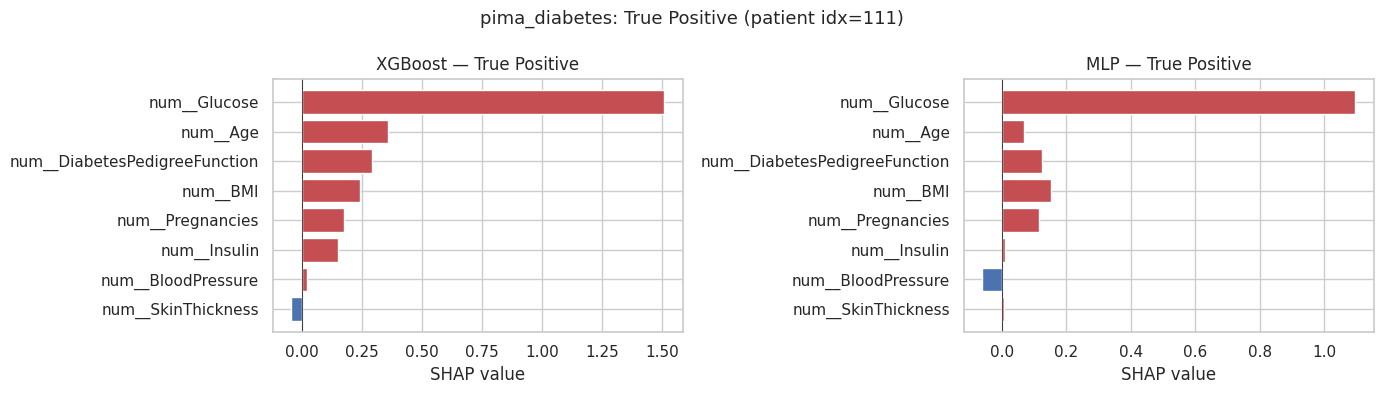

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__Age'), np.str_('num__Glucose'), np.str_('num__DiabetesPedigreeFunction')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Glucose'), np.str_('num__DiabetesPedigreeFunction')}
  Overlap:   {np.str_('num__Glucose'), np.str_('num__DiabetesPedigreeFunction')} (2/3)



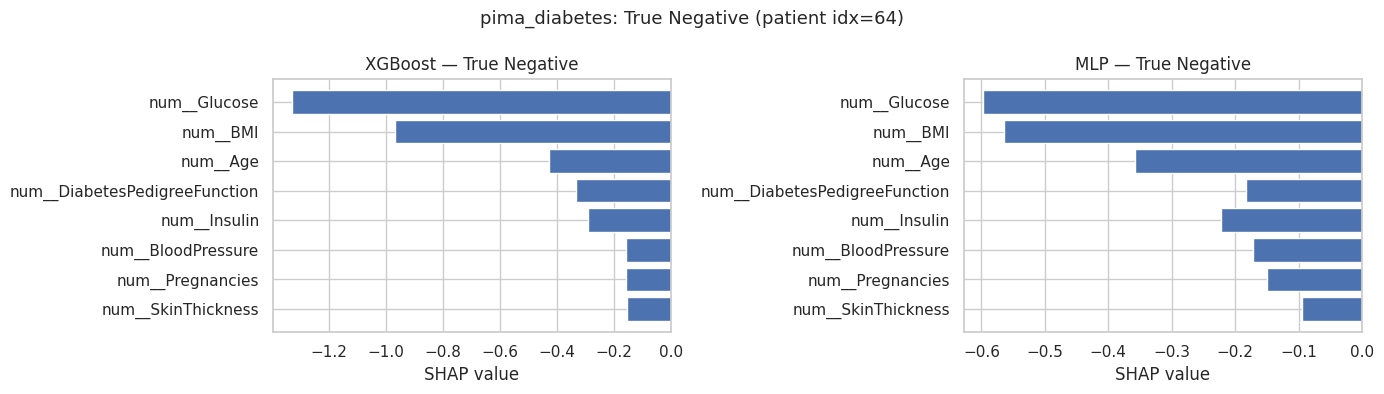

  Sign agreement: 8/8
  Top-3 XGB: {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')}
  Overlap:   {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')} (3/3)



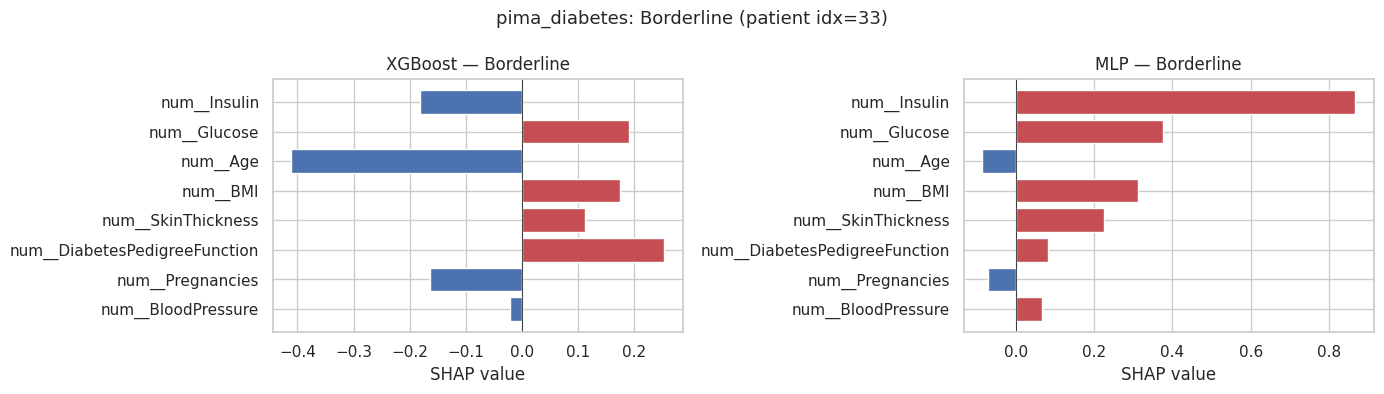

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__Age'), np.str_('num__Glucose'), np.str_('num__DiabetesPedigreeFunction')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Insulin'), np.str_('num__Glucose')}
  Overlap:   {np.str_('num__Glucose')} (1/3)



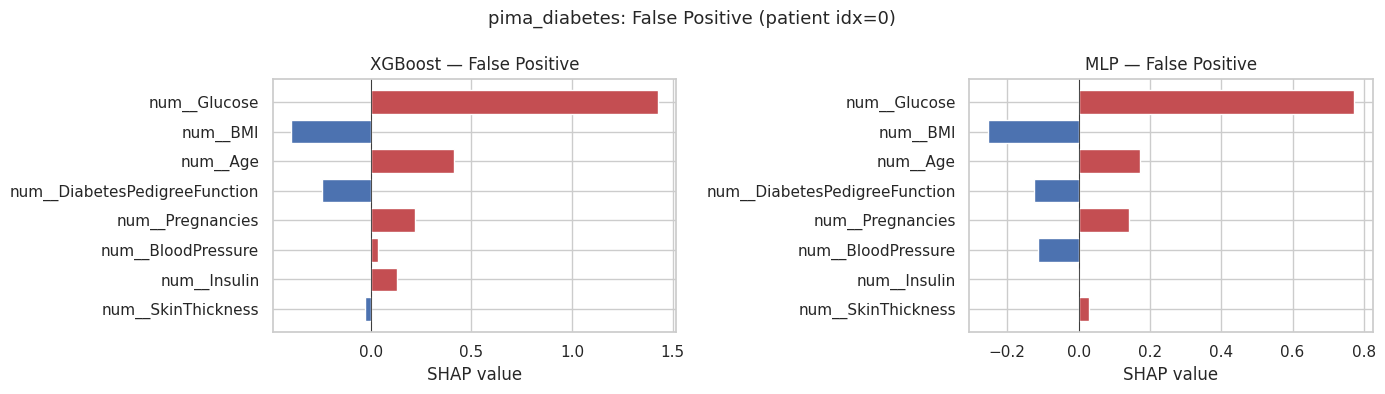

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')}
  Overlap:   {np.str_('num__BMI'), np.str_('num__Age'), np.str_('num__Glucose')} (3/3)



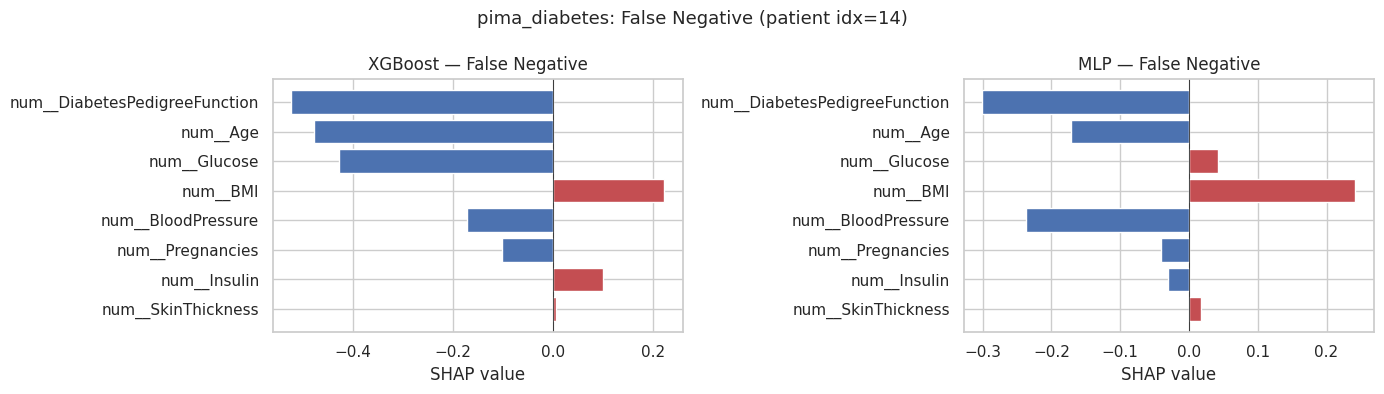

  Sign agreement: 6/8
  Top-3 XGB: {np.str_('num__Age'), np.str_('num__Glucose'), np.str_('num__DiabetesPedigreeFunction')}
  Top-3 MLP: {np.str_('num__BMI'), np.str_('num__BloodPressure'), np.str_('num__DiabetesPedigreeFunction')}
  Overlap:   {np.str_('num__DiabetesPedigreeFunction')} (1/3)


  LOCAL SHAP: diabetes_prediction
Selected: {'True Positive': 217, 'True Negative': 83, 'Borderline': 305, 'False Positive': 19, 'False Negative': 81}


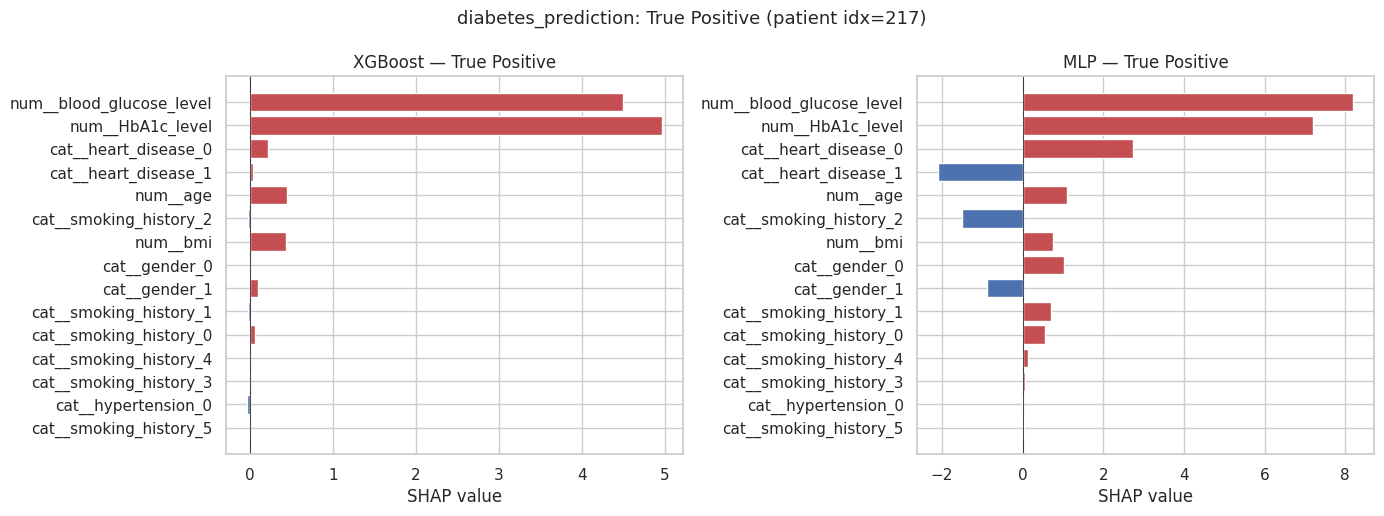

  Sign agreement: 12/17
  Top-3 XGB: {np.str_('num__HbA1c_level'), np.str_('num__age'), np.str_('num__blood_glucose_level')}
  Top-3 MLP: {np.str_('num__HbA1c_level'), np.str_('cat__heart_disease_0'), np.str_('num__blood_glucose_level')}
  Overlap:   {np.str_('num__HbA1c_level'), np.str_('num__blood_glucose_level')} (2/3)



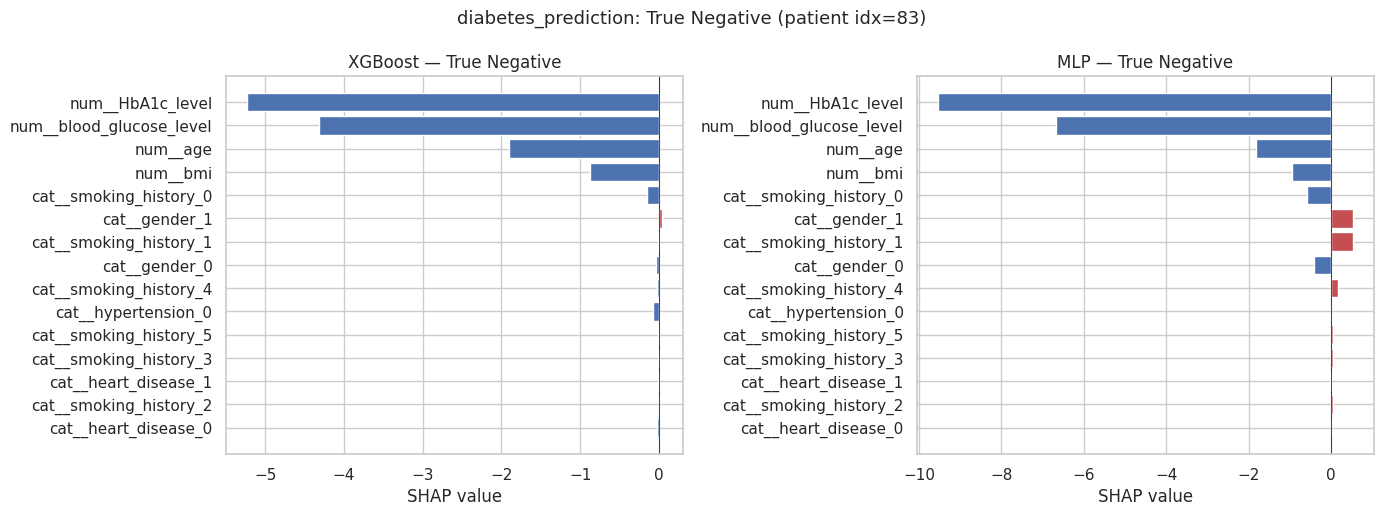

  Sign agreement: 11/17
  Top-3 XGB: {np.str_('num__HbA1c_level'), np.str_('num__age'), np.str_('num__blood_glucose_level')}
  Top-3 MLP: {np.str_('num__HbA1c_level'), np.str_('num__age'), np.str_('num__blood_glucose_level')}
  Overlap:   {np.str_('num__blood_glucose_level'), np.str_('num__HbA1c_level'), np.str_('num__age')} (3/3)



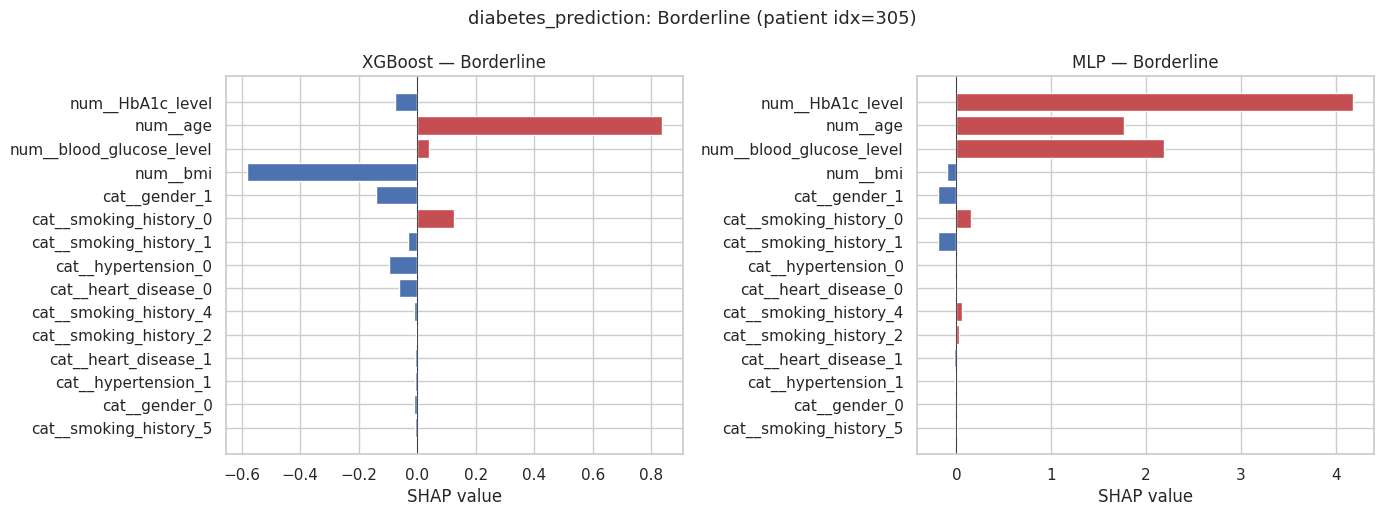

  Sign agreement: 12/17
  Top-3 XGB: {np.str_('num__bmi'), np.str_('cat__gender_1'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__HbA1c_level'), np.str_('num__age'), np.str_('num__blood_glucose_level')}
  Overlap:   {np.str_('num__age')} (1/3)



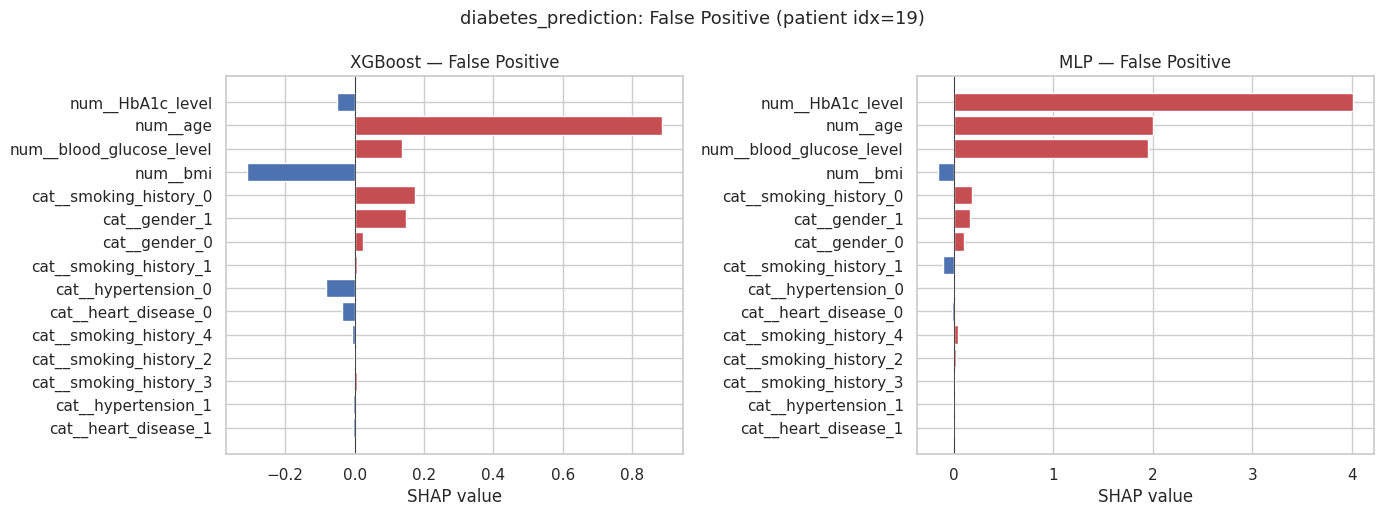

  Sign agreement: 12/17
  Top-3 XGB: {np.str_('cat__smoking_history_0'), np.str_('num__bmi'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__blood_glucose_level'), np.str_('num__HbA1c_level'), np.str_('num__age')}
  Overlap:   {np.str_('num__age')} (1/3)



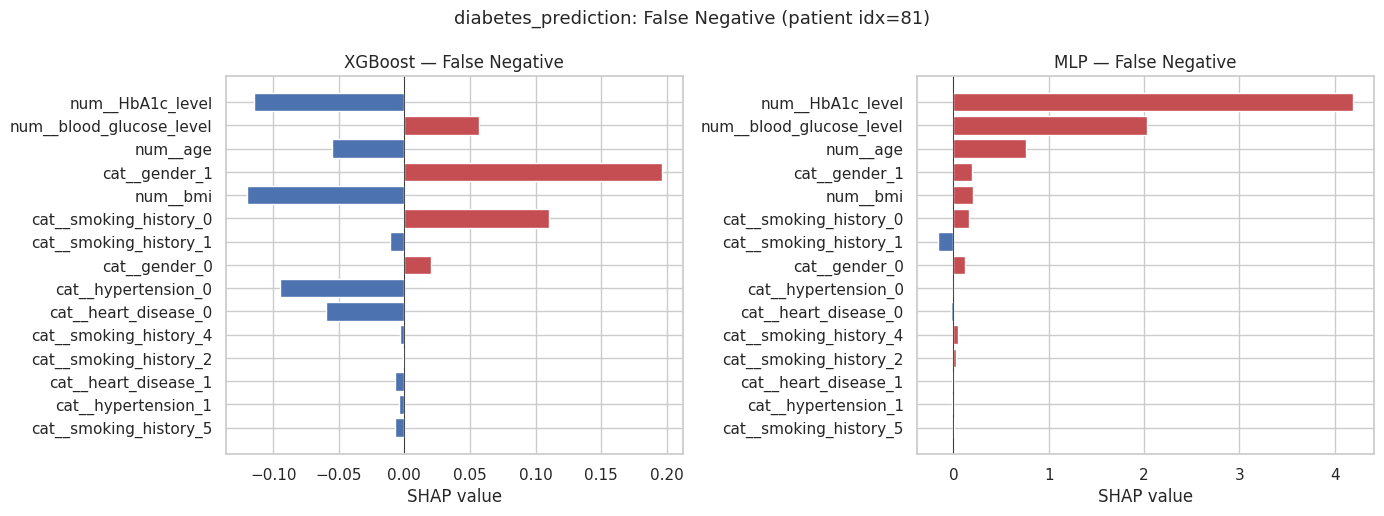

  Sign agreement: 10/17
  Top-3 XGB: {np.str_('num__HbA1c_level'), np.str_('num__bmi'), np.str_('cat__gender_1')}
  Top-3 MLP: {np.str_('num__HbA1c_level'), np.str_('num__age'), np.str_('num__blood_glucose_level')}
  Overlap:   {np.str_('num__HbA1c_level')} (1/3)


  LOCAL SHAP: uci_heart
Selected: {'True Positive': 39, 'True Negative': 21, 'Borderline': 50, 'False Positive': 1, 'False Negative': 11}


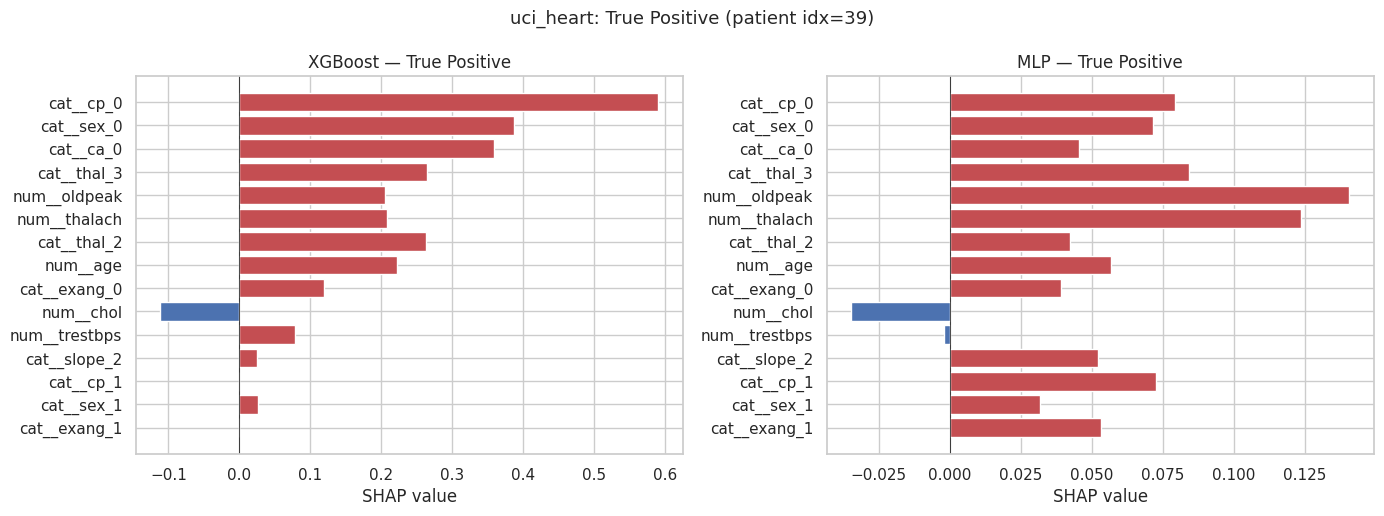

  Sign agreement: 21/30
  Top-3 XGB: {np.str_('cat__cp_0'), np.str_('cat__sex_0'), np.str_('cat__ca_0')}
  Top-3 MLP: {np.str_('num__oldpeak'), np.str_('num__thalach'), np.str_('cat__thal_3')}
  Overlap:   set() (0/3)



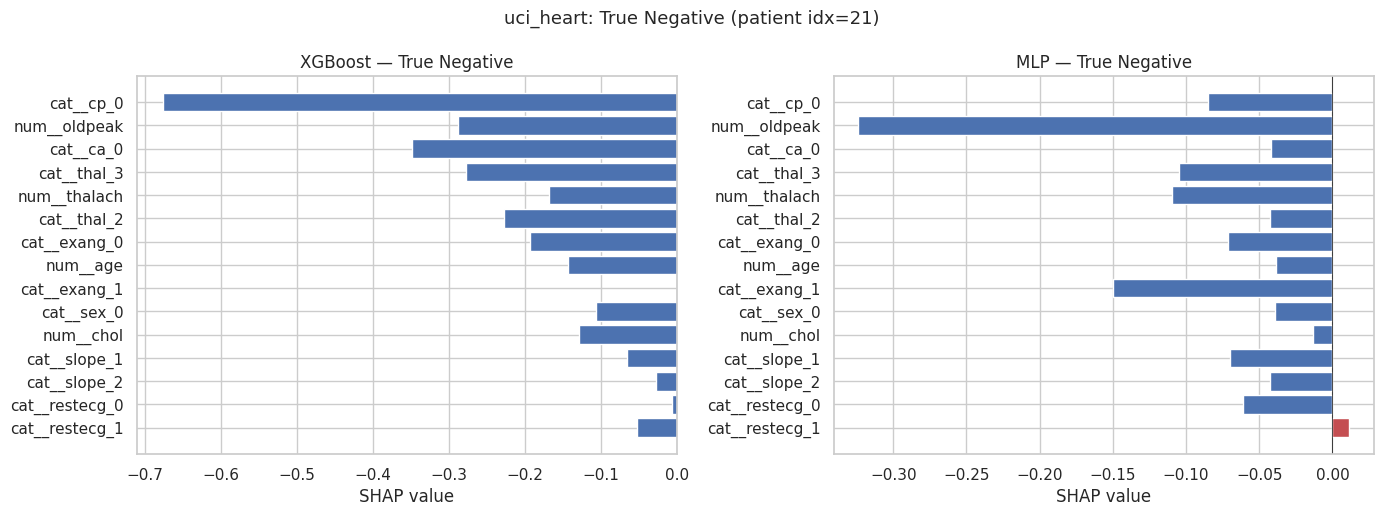

  Sign agreement: 21/30
  Top-3 XGB: {np.str_('num__oldpeak'), np.str_('cat__cp_0'), np.str_('cat__ca_0')}
  Top-3 MLP: {np.str_('num__oldpeak'), np.str_('num__thalach'), np.str_('cat__exang_1')}
  Overlap:   {np.str_('num__oldpeak')} (1/3)



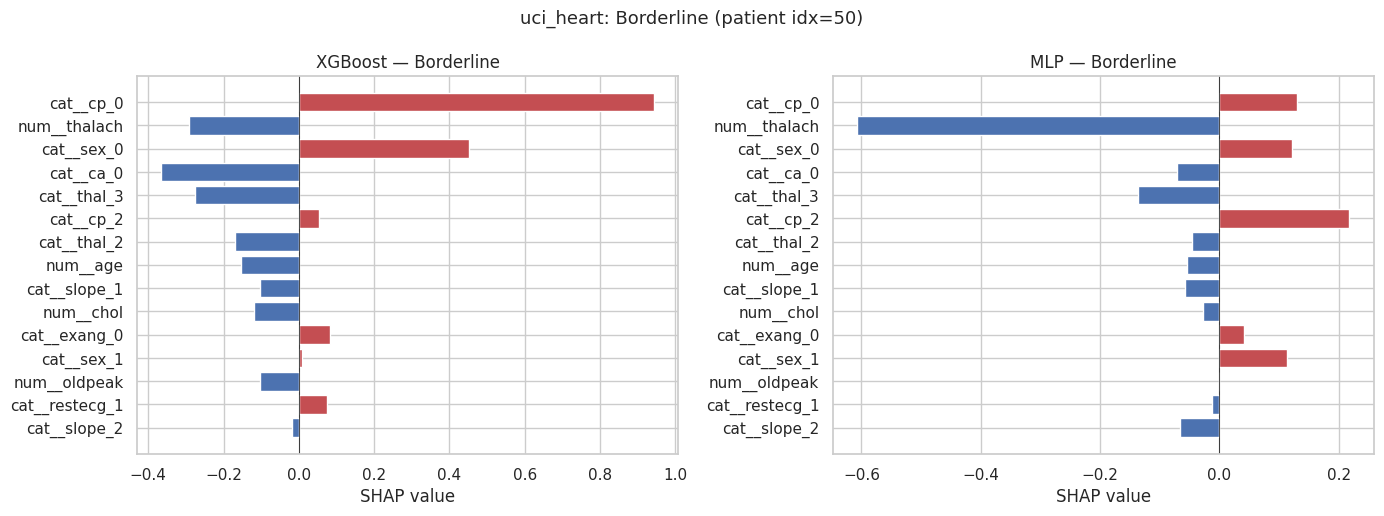

  Sign agreement: 21/30
  Top-3 XGB: {np.str_('cat__cp_0'), np.str_('cat__sex_0'), np.str_('cat__ca_0')}
  Top-3 MLP: {np.str_('cat__cp_2'), np.str_('num__thalach'), np.str_('cat__thal_3')}
  Overlap:   set() (0/3)



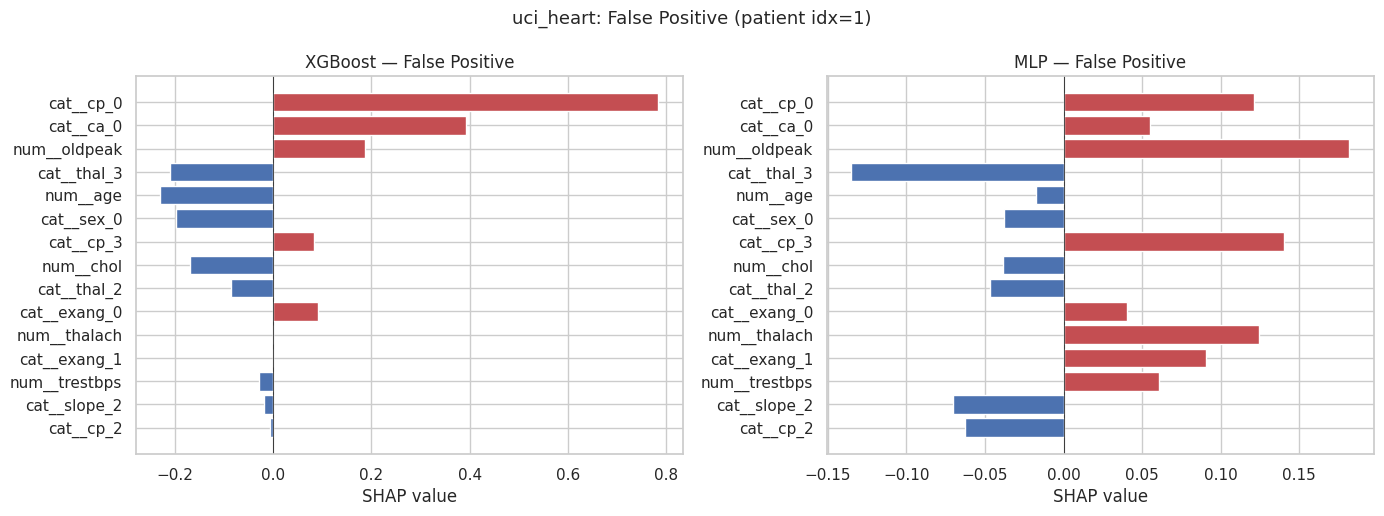

  Sign agreement: 20/30
  Top-3 XGB: {np.str_('cat__cp_0'), np.str_('cat__ca_0'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__oldpeak'), np.str_('cat__cp_3'), np.str_('cat__thal_3')}
  Overlap:   set() (0/3)



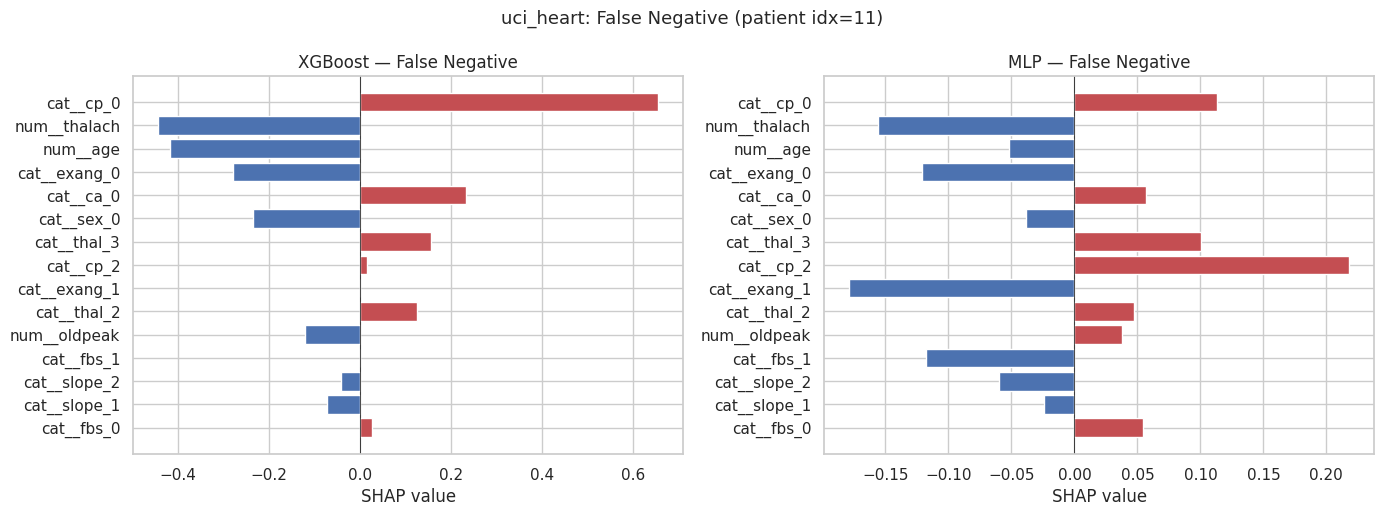

  Sign agreement: 21/30
  Top-3 XGB: {np.str_('num__thalach'), np.str_('cat__cp_0'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__thalach'), np.str_('cat__cp_2'), np.str_('cat__exang_1')}
  Overlap:   {np.str_('num__thalach')} (1/3)


  LOCAL SHAP: heart_disease_prediction
Selected: {'True Positive': 113, 'True Negative': 65, 'Borderline': 456, 'False Positive': 6, 'False Negative': 13}


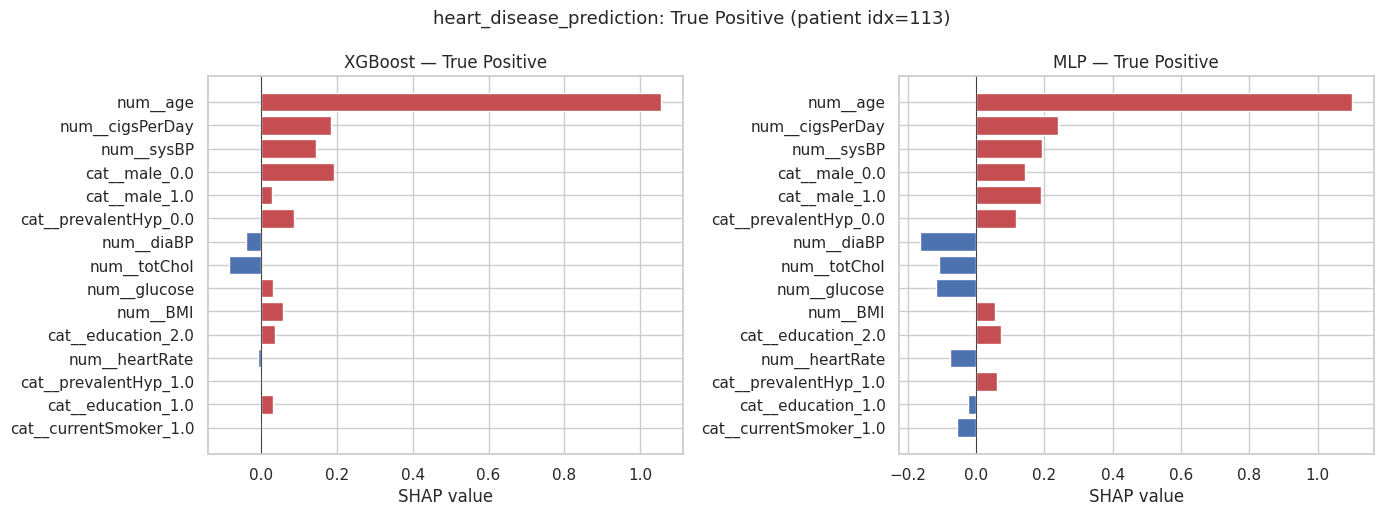

  Sign agreement: 16/24
  Top-3 XGB: {np.str_('cat__male_0.0'), np.str_('num__cigsPerDay'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__cigsPerDay'), np.str_('num__sysBP'), np.str_('num__age')}
  Overlap:   {np.str_('num__cigsPerDay'), np.str_('num__age')} (2/3)



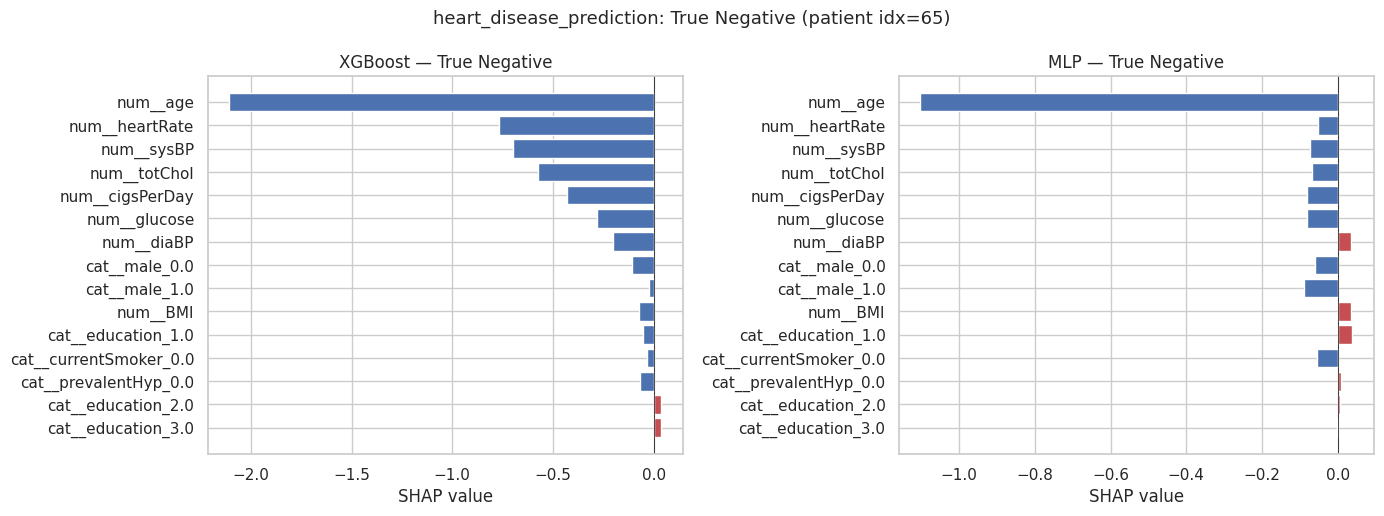

  Sign agreement: 14/24
  Top-3 XGB: {np.str_('num__sysBP'), np.str_('num__heartRate'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__cigsPerDay'), np.str_('cat__male_1.0'), np.str_('num__age')}
  Overlap:   {np.str_('num__age')} (1/3)



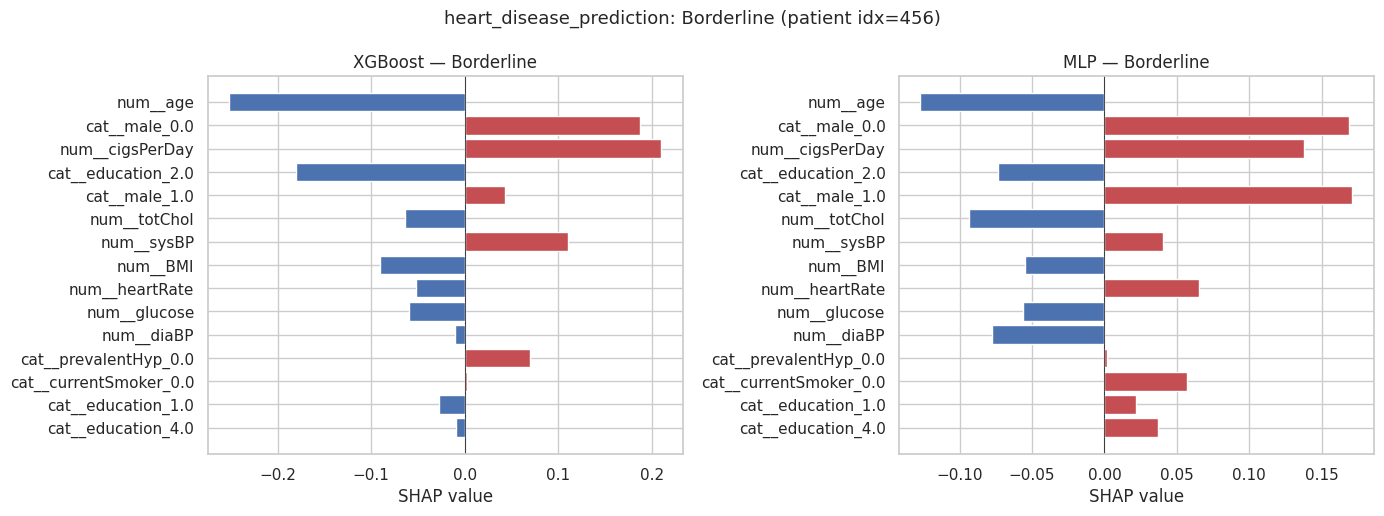

  Sign agreement: 17/24
  Top-3 XGB: {np.str_('num__cigsPerDay'), np.str_('cat__male_0.0'), np.str_('num__age')}
  Top-3 MLP: {np.str_('cat__male_0.0'), np.str_('num__cigsPerDay'), np.str_('cat__male_1.0')}
  Overlap:   {np.str_('cat__male_0.0'), np.str_('num__cigsPerDay')} (2/3)



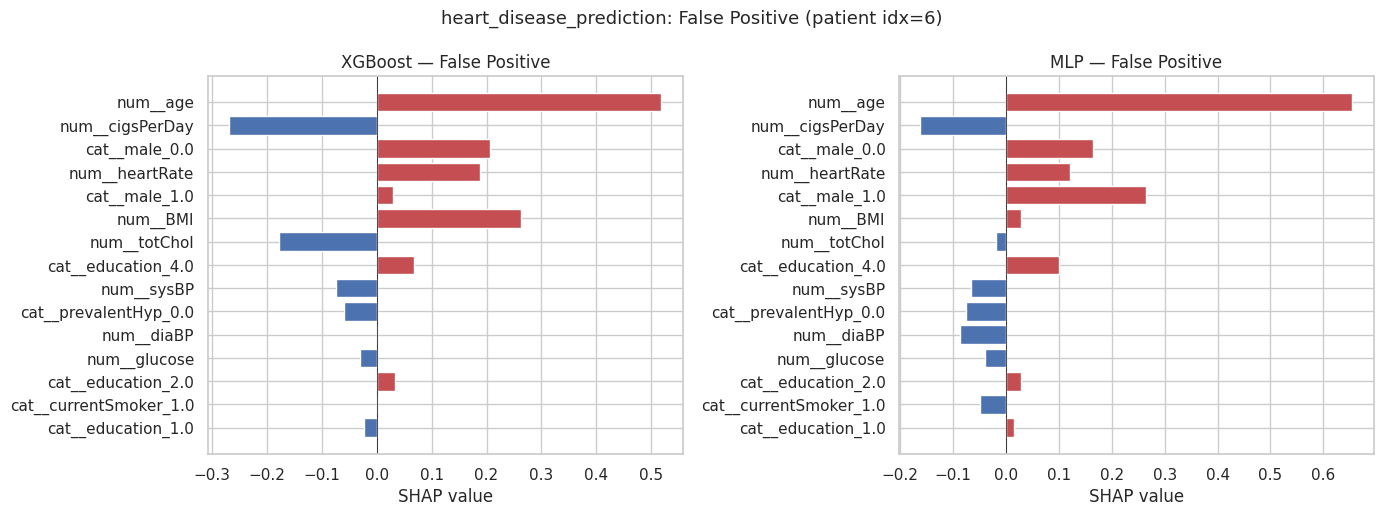

  Sign agreement: 17/24
  Top-3 XGB: {np.str_('num__cigsPerDay'), np.str_('num__BMI'), np.str_('num__age')}
  Top-3 MLP: {np.str_('cat__male_0.0'), np.str_('cat__male_1.0'), np.str_('num__age')}
  Overlap:   {np.str_('num__age')} (1/3)



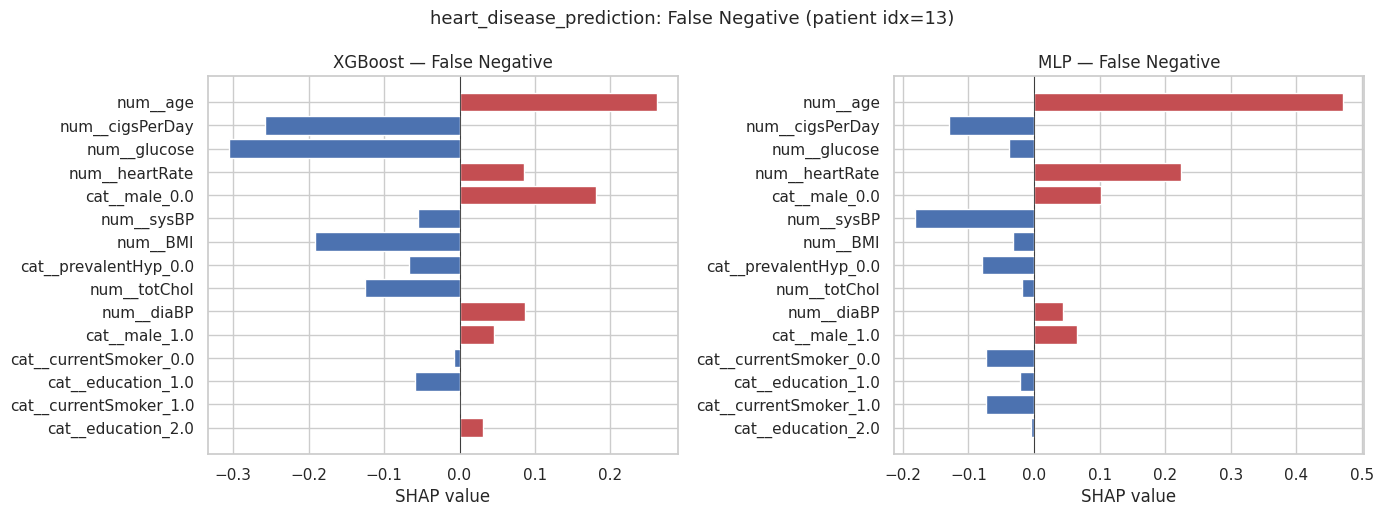

  Sign agreement: 17/24
  Top-3 XGB: {np.str_('num__cigsPerDay'), np.str_('num__glucose'), np.str_('num__age')}
  Top-3 MLP: {np.str_('num__sysBP'), np.str_('num__heartRate'), np.str_('num__age')}
  Overlap:   {np.str_('num__age')} (1/3)



In [ ]:
def select_patients(result):
    """Select 5 representative patients from the SHAP sample."""
    y = result["y_sample"]
    xgb_prob = result["xgb_proba"]
    mlp_prob = result["mlp_proba"]
    xgb_pred = (xgb_prob >= 0.5).astype(int)

    df = pd.DataFrame({
        "y_true": y,
        "xgb_pred": xgb_pred,
        "xgb_prob": xgb_prob,
        "mlp_prob": mlp_prob,
    }).reset_index(drop=True)

    patients = {}

    tp = df[(df["y_true"] == 1) & (df["xgb_pred"] == 1)]
    if len(tp) > 0:
        patients["True Positive"] = int(tp["xgb_prob"].idxmax())

    tn = df[(df["y_true"] == 0) & (df["xgb_pred"] == 0)]
    if len(tn) > 0:
        patients["True Negative"] = int(tn["xgb_prob"].idxmin())

    patients["Borderline"] = int((df["xgb_prob"] - 0.5).abs().idxmin())

    fp = df[(df["y_true"] == 0) & (df["xgb_pred"] == 1)]
    if len(fp) > 0:
        patients["False Positive"] = int(fp.index[0])

    fn = df[(df["y_true"] == 1) & (df["xgb_pred"] == 0)]
    if len(fn) > 0:
        patients["False Negative"] = int(fn.index[0])

    return patients


def plot_patient_local_shap(result, patients):
    """For each archetype, side-by-side bar charts of SHAP values."""
    feature_names = result["feature_names"]
    n_features = len(feature_names)
    # Cap displayed features
    show_n = min(15, n_features)

    for ptype, idx in patients.items():
        xgb_vals = result["shap_xgb"][idx]
        mlp_vals = result["shap_mlp"][idx]

        # Pick top features by combined importance for cleaner plot
        combined_importance = np.abs(xgb_vals) + np.abs(mlp_vals)
        top_idx = np.argsort(-combined_importance)[:show_n]
        feat_subset = [feature_names[i] for i in top_idx]
        xgb_subset = xgb_vals[top_idx]
        mlp_subset = mlp_vals[top_idx]

        fig, axes = plt.subplots(1, 2, figsize=(14, max(4, show_n * 0.35)))
        y_pos = np.arange(show_n)

        axes[0].barh(y_pos, xgb_subset,
                     color=["#C44E52" if v > 0 else "#4C72B0" for v in xgb_subset])
        axes[0].set_yticks(y_pos)
        axes[0].set_yticklabels(feat_subset)
        axes[0].invert_yaxis()
        axes[0].set_title(f"XGBoost — {ptype}")
        axes[0].set_xlabel("SHAP value")
        axes[0].axvline(0, color="black", linewidth=0.5)

        axes[1].barh(y_pos, mlp_subset,
                     color=["#C44E52" if v > 0 else "#4C72B0" for v in mlp_subset])
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(feat_subset)
        axes[1].invert_yaxis()
        axes[1].set_title(f"MLP — {ptype}")
        axes[1].set_xlabel("SHAP value")
        axes[1].axvline(0, color="black", linewidth=0.5)

        plt.suptitle(f"{result['dataset']}: {ptype} (patient idx={idx})", fontsize=13)
        plt.tight_layout()
        plt.show()

        # Quick metrics
        sign_agree = np.sum(np.sign(xgb_vals) == np.sign(mlp_vals))
        top3_xgb = set(np.array(feature_names)[np.argsort(-np.abs(xgb_vals))[:3]])
        top3_mlp = set(np.array(feature_names)[np.argsort(-np.abs(mlp_vals))[:3]])
        overlap = top3_xgb & top3_mlp
        print(f"  Sign agreement: {sign_agree}/{n_features}")
        print(f"  Top-3 XGB: {top3_xgb}")
        print(f"  Top-3 MLP: {top3_mlp}")
        print(f"  Overlap:   {overlap} ({len(overlap)}/3)\n")

# Run for each dataset
for name, result in shap_results.items():
    print(f"\n{'='*60}\n  LOCAL SHAP: {name}\n{'='*60}")
    patients = select_patients(result)
    print(f"Selected: {patients}")
    plot_patient_local_shap(result, patients)

### Cell: Cross-Dataset Summary

In [ ]:
summary = pd.DataFrame([
    {
        "Dataset": name,
        "Spearman_rho": round(r["rho"], 4),
        "Top3_overlap": f"{r['top3_overlap']}/3",
        "Disease": "Diabetes" if "diabetes" in name or "pima" in name else "Heart",
    }
    for name, r in ranking_results.items()
])
print("=== CROSS-DATASET SHAP CONSISTENCY ===\n")
display(summary)

diab_avg = summary[summary["Disease"]=="Diabetes"]["Spearman_rho"].mean()
heart_avg = summary[summary["Disease"]=="Heart"]["Spearman_rho"].mean()

print(f"\nDiabetes average ρ: {diab_avg:.4f}")
print(f"Heart average ρ:    {heart_avg:.4f}")

if abs(diab_avg - heart_avg) < 0.1:
    print("\n→ Consistency is similar across diseases.")
    print("  Any divergence pattern appears to be a property of the MODEL ARCHITECTURE,")
    print("  not the disease domain. This is your governance finding.")
else:
    print(f"\n→ Consistency differs between diseases (gap = {abs(diab_avg-heart_avg):.4f}).")
    print("  Divergence patterns may be DISEASE-SPECIFIC.")
    print("  This complicates the generalization claim.")

=== CROSS-DATASET SHAP CONSISTENCY ===



,Dataset,Spearman_rho,Top3_overlap,Disease
0,pima_diabetes,0.9762,3/3,Diabetes
1,diabetes_prediction,0.7157,3/3,Diabetes
2,uci_heart,0.6222,0/3,Heart
3,heart_disease_prediction,0.8494,3/3,Heart



Diabetes average ρ: 0.8459
Heart average ρ:    0.7358

→ Consistency differs between diseases (gap = 0.1101).
  Divergence patterns may be DISEASE-SPECIFIC.
  This complicates the generalization claim.
